# OMIE Data Validation & Structural Statistics

**Purpose:** Exploratory only — not thesis output.

1. Spot-validate prices against the OMIE website
2. Spot-validate aggregate supply/demand curves
3. Structural statistics around the MTU15 reform

Reform dates:
- Intraday auctions + continuous: **2025-03-19**
- Day-ahead market: **2025-10-01**

In [423]:
from pathlib import Path
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

PROJECT_ROOT = Path("../").resolve()

MARGINALPDBC  = PROJECT_ROOT / "data/processed/omie/mercado_diario/precios/marginalpdbc_all.parquet"
MARGINALPIBC  = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_subastas/precios/marginalpibc_all.parquet"
CURVA_PBC_DIR = PROJECT_ROOT / "data/processed/omie/mercado_diario/curvas/curva_pbc"

# Structural breaks (all dates = first day of new regime)
IDA_REFORM       = pd.Timestamp("2024-06-14")  # 6 local MIBEL sessions → 3 European IDA sessions
INTRADAY_REFORM  = pd.Timestamp("2025-03-19")  # MTU60 → MTU15 for intraday auctions + continuous
DAY_AHEAD_REFORM = pd.Timestamp("2025-10-01")  # MTU60 → MTU15 for day-ahead market

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

---
## Section 1 — Price spot-validation

Compare with: https://www.omie.es/es/market-results/daily/daily-market/day-ahead-price?scope=daily&date=CHECK_DATE

In [424]:
CHECK_DATE = "2026-04-10"  # <-- change to any date to spot-check

df = pd.read_parquet(MARGINALPDBC)
day = df[df["date"] == CHECK_DATE].sort_values("period")[["period", "price_es_eur_mwh", "price_pt_eur_mwh"]]

print(f"Date: {CHECK_DATE}  |  MTU: {df.loc[df['date']==CHECK_DATE, 'mtu_minutes'].iloc[0]} min  |  Periods: {len(day)}")
print(day.to_string(index=False))

Date: 2026-04-07  |  MTU: 15 min  |  Periods: 96
 period  price_es_eur_mwh  price_pt_eur_mwh
      1             35.01             35.01
      2             35.01             35.01
      3             35.00             35.00
      4             23.90             23.90
      5             31.83             31.83
      6             31.00             31.00
      7             30.00             30.00
      8             23.89             23.89
      9             23.90             23.90
     10             23.64             23.64
     11             23.43             23.43
     12             23.25             23.25
     13             23.25             23.25
     14             23.12             23.12
     15             20.89             20.89
     16             23.12             23.12
     17             23.25             23.25
     18             23.38             23.38
     19             23.43             23.43
     20             23.64             23.64
     21             23.90  

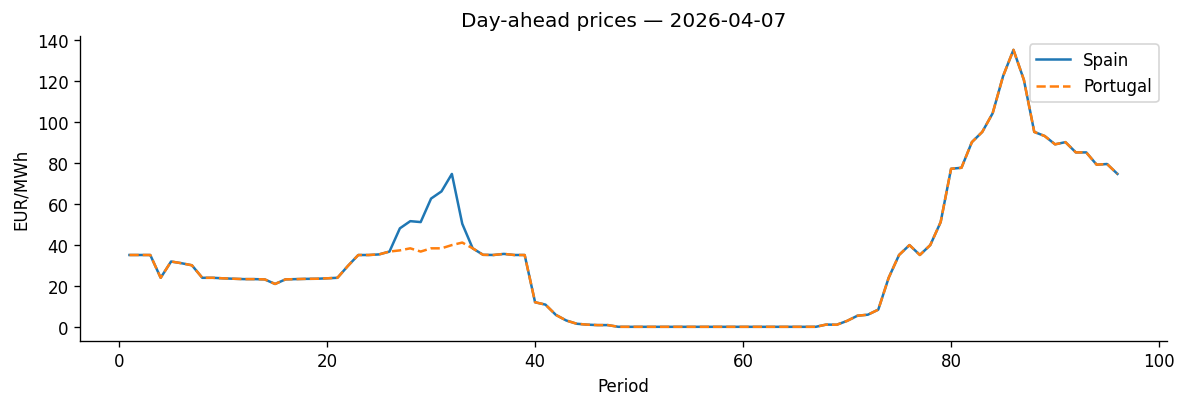

In [425]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(day["period"], day["price_es_eur_mwh"], label="Spain", linewidth=1.5)
ax.plot(day["period"], day["price_pt_eur_mwh"], label="Portugal", linewidth=1.5, linestyle="--")
ax.set_xlabel("Period")
ax.set_ylabel("EUR/MWh")
ax.set_title(f"Day-ahead prices — {CHECK_DATE}")
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 2 — Aggregate curve spot-validation

Compare with: https://www.omie.es/es/market-results/daily/daily-market/aggragate-suply-curves?scope=daily&date=CHECK_DATE

In [426]:
CHECK_DATE_CURVE = "2026-04-08"  # <-- change to any date
CHECK_PERIOD     = 20            # <-- period number (1-24 for MTU60, 1-96 for MTU15)

# country='MI' = Iberian market aggregate curve (what OMIE shows on the website).
# country='ES'/'PT' only appear post-reform for periods with market splitting (price separation).
glob = str(CURVA_PBC_DIR / "*.parquet")
df_curve = duckdb.query(
    f"SELECT * FROM read_parquet('{glob}', union_by_name=true) "
    f"WHERE date='{CHECK_DATE_CURVE}' AND period_num={CHECK_PERIOD} AND country='MI'"
).df()

print(f"Rows for date={CHECK_DATE_CURVE}, period={CHECK_PERIOD}, country=MI: {len(df_curve)}")
print(df_curve[["offer_type", "curve_type", "power_mw", "price_eur_mwh"]].head(10))

Rows for date=2026-04-07, period=20, country=MI: 3779
  offer_type curve_type  power_mw  price_eur_mwh
0          C          O      19.2         1500.0
1          C          O     340.4         1500.0
2          C          O     120.2         1500.0
3          C          O      15.9          501.0
4          C          O     197.7          501.0
5          C          O    1570.8          501.0
6          C          O     137.9          500.0
7          C          O       1.4          500.0
8          C          O      44.9          500.0
9          C          O     272.2          500.0


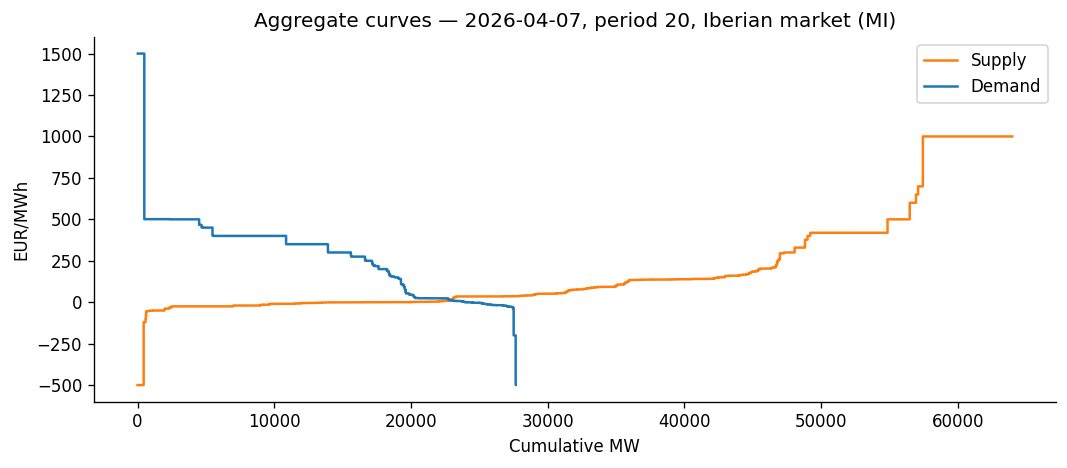

In [427]:
def build_staircase(df_steps, price_col="price_eur_mwh", power_col="power_mw", ascending=True):
    """Sort steps by price and compute cumulative MW."""
    s = df_steps.sort_values(price_col, ascending=ascending).copy()
    s["cum_mw"] = s[power_col].cumsum()
    return s

supply = build_staircase(
    df_curve[(df_curve["offer_type"] == "V") & (df_curve["curve_type"] == "O")],
    ascending=True,
)
demand = build_staircase(
    df_curve[(df_curve["offer_type"] == "C") & (df_curve["curve_type"] == "O")],
    ascending=False,  # demand curve: high prices first
)

fig, ax = plt.subplots(figsize=(9, 4))
if not supply.empty:
    ax.step(supply["cum_mw"], supply["price_eur_mwh"], where="post", label="Supply", color="tab:orange")
if not demand.empty:
    ax.step(demand["cum_mw"], demand["price_eur_mwh"], where="post", label="Demand", color="tab:blue")
ax.set_xlabel("Cumulative MW")
ax.set_ylabel("EUR/MWh")
ax.set_title(f"Aggregate curves — {CHECK_DATE_CURVE}, period {CHECK_PERIOD}, Iberian market (MI)")
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 3 — Structural statistics

> **Note on price levels:** Price changes reflect renewable growth, regulation, and the MTU15 reform simultaneously. Price-level comparisons are not clean reform signals. Focus on *structural* metrics.

In [428]:
# Load full price dataset once
df_prices = pd.read_parquet(MARGINALPDBC)
df_prices["date"] = pd.to_datetime(df_prices["date"])
print(f"marginalpdbc: {len(df_prices):,} rows, {df_prices['date'].min().date()} → {df_prices['date'].max().date()}")

marginalpdbc: 84,431 rows, 2018-01-01 → 2026-04-08


### 3a. Within-day price profile
Mean price by period-of-day, pre-reform vs post-reform. Shows the intra-hour resolution gain.

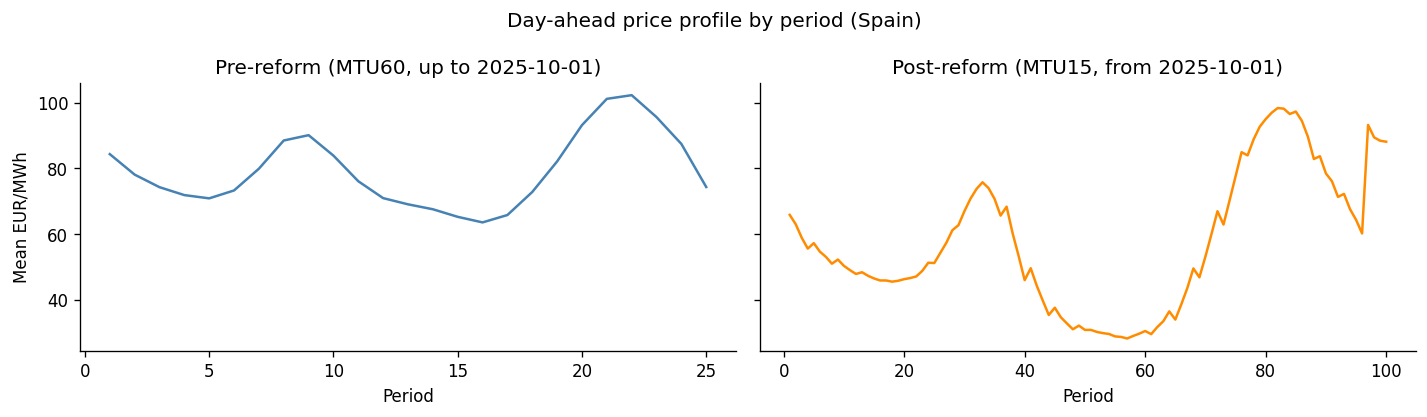

In [429]:
pre  = df_prices[df_prices["date"] < DAY_AHEAD_REFORM]
post = df_prices[df_prices["date"] >= DAY_AHEAD_REFORM]

pre_profile  = pre.groupby("period")["price_es_eur_mwh"].mean()
post_profile = post.groupby("period")["price_es_eur_mwh"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
axes[0].plot(pre_profile.index,  pre_profile.values,  linewidth=1.5, color="steelblue")
axes[0].set_title(f"Pre-reform (MTU60, up to {DAY_AHEAD_REFORM.date()})")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Mean EUR/MWh")

axes[1].plot(post_profile.index, post_profile.values, linewidth=1.5, color="darkorange")
axes[1].set_title(f"Post-reform (MTU15, from {DAY_AHEAD_REFORM.date()})")
axes[1].set_xlabel("Period")

plt.suptitle("Day-ahead price profile by period (Spain)", fontsize=12)
plt.tight_layout()
plt.show()

### 3b. Intra-hour price dispersion — core MTU15 metric
Post-reform only. For each hour, compute std dev of the 4 quarter-hour prices.
This quantifies the price variation that was invisible under hourly trading.

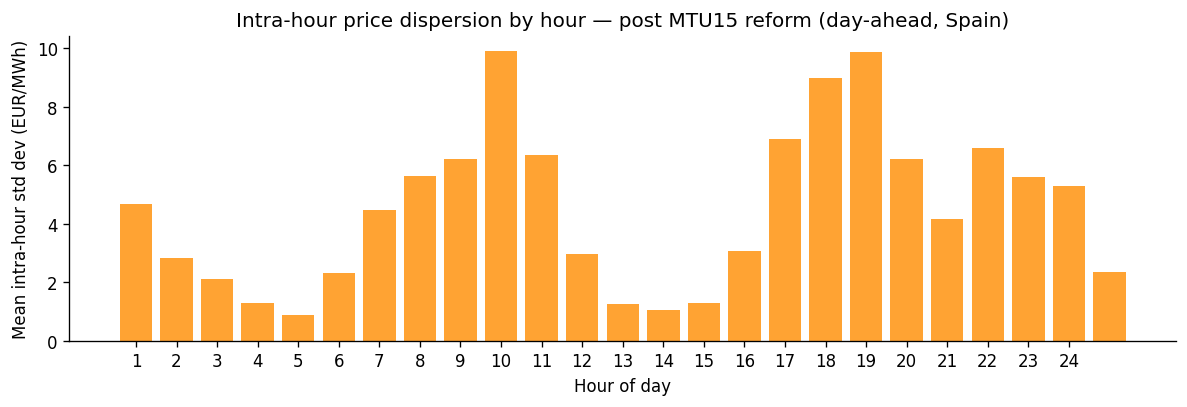

Overall mean intra-hour std dev: 4.49 EUR/MWh
Max (hour 10): 9.92 EUR/MWh


In [430]:
post_mtu15 = df_prices[(df_prices["date"] >= DAY_AHEAD_REFORM) & (df_prices["mtu_minutes"] == 15)].copy()
# Map period (1-96) to hour-of-day (1-24)
post_mtu15["hour"] = ((post_mtu15["period"] - 1) // 4) + 1

# Std dev of 4 quarter-hour prices within each (date, hour)
intra_hour_std = (
    post_mtu15.groupby(["date", "hour"])["price_es_eur_mwh"]
    .std()
    .reset_index()
    .groupby("hour")["price_es_eur_mwh"]
    .mean()  # average across days
)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(intra_hour_std.index, intra_hour_std.values, color="darkorange", alpha=0.8)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean intra-hour std dev (EUR/MWh)")
ax.set_title("Intra-hour price dispersion by hour — post MTU15 reform (day-ahead, Spain)")
ax.set_xticks(range(1, 25))
plt.tight_layout()
plt.show()

print(f"Overall mean intra-hour std dev: {intra_hour_std.mean():.2f} EUR/MWh")
print(f"Max (hour {intra_hour_std.idxmax()}): {intra_hour_std.max():.2f} EUR/MWh")

### 3c. Monthly price level
Price level context only — **not a clean reform signal** (renewables + policy confound).

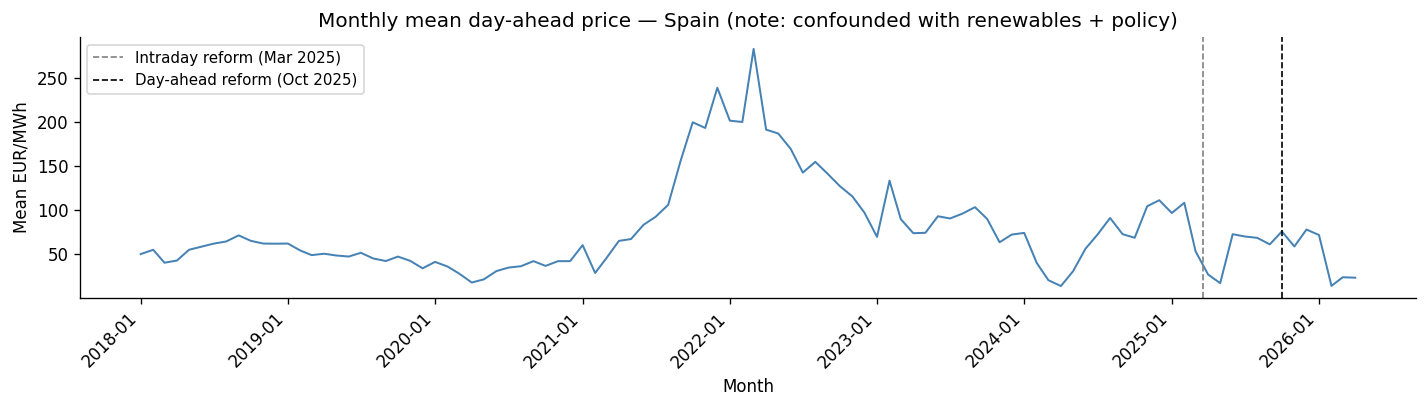

In [431]:
monthly = (
    df_prices.groupby(df_prices["date"].dt.to_period("M"))["price_es_eur_mwh"]
    .mean()
    .reset_index()
)
monthly["date"] = monthly["date"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(monthly["date"], monthly["price_es_eur_mwh"], linewidth=1.2, color="steelblue")
ax.axvline(INTRADAY_REFORM,  color="gray",   linestyle="--", linewidth=1, label="Intraday reform (Mar 2025)")
ax.axvline(DAY_AHEAD_REFORM, color="black",  linestyle="--", linewidth=1, label="Day-ahead reform (Oct 2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Mean EUR/MWh")
ax.set_title("Monthly mean day-ahead price — Spain (note: confounded with renewables + policy)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 3d. Intraday auction prices across regimes

Three regimes in the data:
- **Pre-IDA** (before 2024-06-14): 6 local MIBEL sessions, MTU60
- **IDA MTU60** (2024-06-14 – 2025-03-18): 3 European sessions (IDA1–IDA3), MTU60
- **IDA MTU15** (from 2025-03-19): 3 European sessions, MTU15

Note: IDA3 only covers afternoon delivery (D 12h–24h), so some days legitimately have only 2 sessions.

── Intraday reform (MTU15 intraday auctions) (reform: 2025-03-19) ──
  Before (2025-02-19 → 2025-03-18): mean=78.82, median=79.18, std=38.91 EUR/MWh  (n=28 days)
  After  (2025-03-19 → 2025-04-18): mean=26.33, median=14.00, std=34.92 EUR/MWh  (n=31 days)
  Change: -66.6%



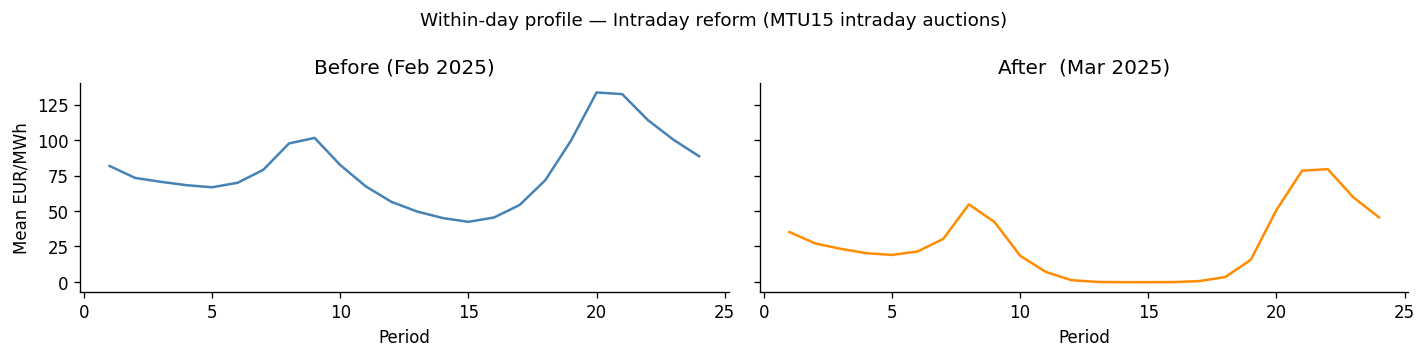

── Day-ahead reform (MTU15 day-ahead) (reform: 2025-10-01) ──
  Before (2025-09-01 → 2025-09-30): mean=61.04, median=66.63, std=42.90 EUR/MWh  (n=30 days)
  After  (2025-10-01 → 2025-10-31): mean=75.75, median=83.61, std=44.55 EUR/MWh  (n=31 days)
  Change: +24.1%



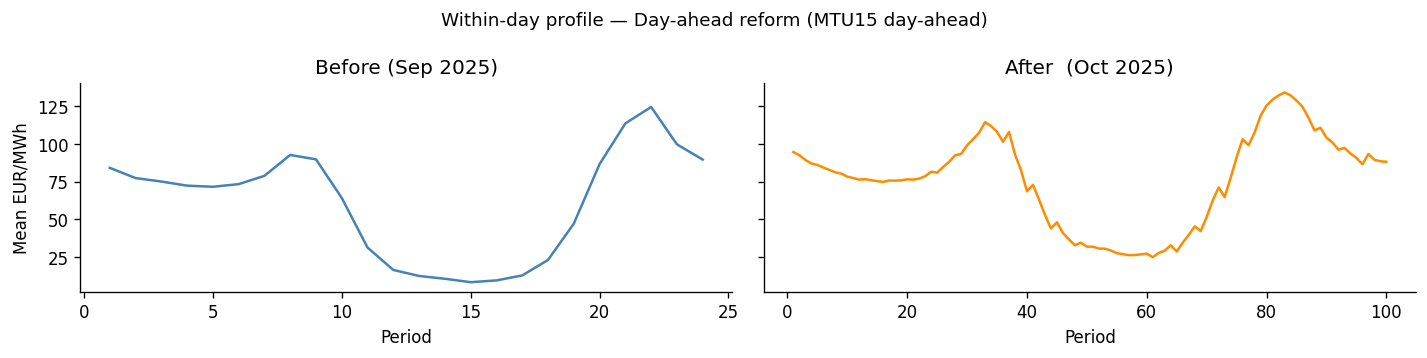

In [432]:
from dateutil.relativedelta import relativedelta

def compare_around_reform(df, reform_date, label, window_months=1):
    before = df[
        (df["date"] >= reform_date - relativedelta(months=window_months)) &
        (df["date"] <  reform_date)
    ]
    after = df[
        (df["date"] >= reform_date) &
        (df["date"] <  reform_date + relativedelta(months=window_months))
    ]
    print(f"── {label} (reform: {reform_date.date()}) ──")
    print(f"  Before ({before['date'].min().date()} → {before['date'].max().date()}): "
          f"mean={before['price_es_eur_mwh'].mean():.2f}, "
          f"median={before['price_es_eur_mwh'].median():.2f}, "
          f"std={before['price_es_eur_mwh'].std():.2f} EUR/MWh  (n={before['date'].nunique()} days)")
    print(f"  After  ({after['date'].min().date()} → {after['date'].max().date()}): "
          f"mean={after['price_es_eur_mwh'].mean():.2f}, "
          f"median={after['price_es_eur_mwh'].median():.2f}, "
          f"std={after['price_es_eur_mwh'].std():.2f} EUR/MWh  (n={after['date'].nunique()} days)")
    pct = (after['price_es_eur_mwh'].mean() - before['price_es_eur_mwh'].mean()) / before['price_es_eur_mwh'].mean() * 100
    print(f"  Change: {pct:+.1f}%\n")

    # Within-day profile comparison (only meaningful if both sides have data)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
    for ax, subset, sublabel, color in [
        (axes[0], before, f"Before ({(reform_date - relativedelta(months=window_months)).strftime('%b %Y')})", "steelblue"),
        (axes[1], after,  f"After  ({reform_date.strftime('%b %Y')})", "darkorange"),
    ]:
        profile = subset.groupby("period")["price_es_eur_mwh"].mean()
        ax.plot(profile.index, profile.values, linewidth=1.5, color=color)
        ax.set_title(sublabel)
        ax.set_xlabel("Period")
    axes[0].set_ylabel("Mean EUR/MWh")
    plt.suptitle(f"Within-day profile — {label}", fontsize=11)
    plt.tight_layout()
    plt.show()

compare_around_reform(df_prices, INTRADAY_REFORM,  "Intraday reform (MTU15 intraday auctions)")
compare_around_reform(df_prices, DAY_AHEAD_REFORM, "Day-ahead reform (MTU15 day-ahead)")

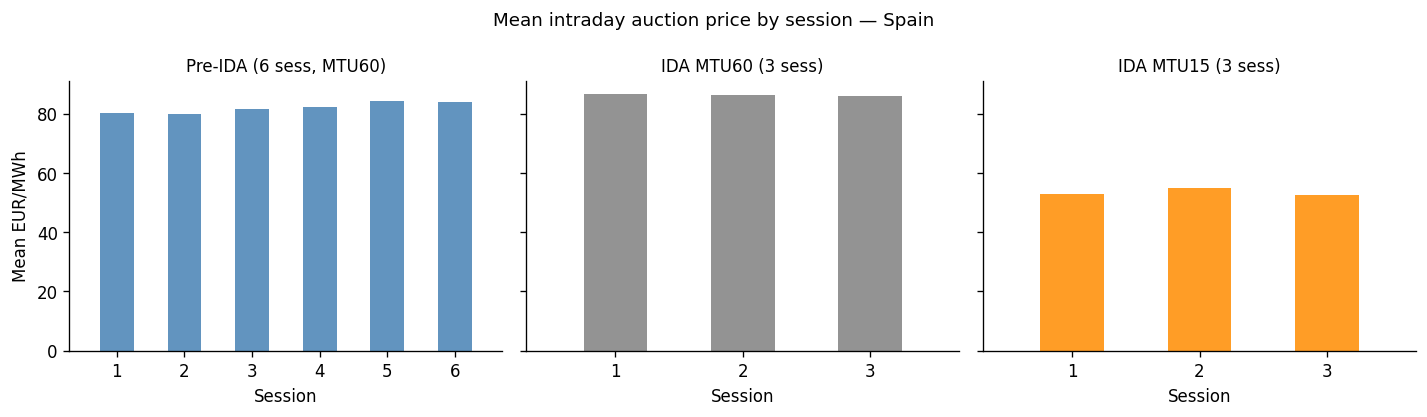

Cross-session price convergence (std dev across sessions per day):
  Pre-IDA (6 sess, MTU60): mean std = 3.48 EUR/MWh  (n = 2351 days with all 6 sessions)
  IDA MTU60 (3 sess): mean std = 6.03 EUR/MWh  (n = 259 days with all 3 sessions)
  IDA MTU15 (3 sess): mean std = 5.74 EUR/MWh  (n = 319 days with all 3 sessions)


In [433]:
IDA_TRANSITION = pd.Timestamp("2024-06-14")  # confirmed from data: last 6-session day was 2024-06-13

df_pibc = pd.read_parquet(MARGINALPIBC)
df_pibc["date"] = pd.to_datetime(df_pibc["date"])

pre_ida   = df_pibc[df_pibc["date"] <  IDA_TRANSITION]
ida_mtu60 = df_pibc[(df_pibc["date"] >= IDA_TRANSITION) & (df_pibc["date"] < INTRADAY_REFORM)]
ida_mtu15 = df_pibc[df_pibc["date"] >= INTRADAY_REFORM]

regimes = [
    ("Pre-IDA (6 sess, MTU60)", pre_ida,   "steelblue",  6),
    ("IDA MTU60 (3 sess)",       ida_mtu60, "gray",       3),
    ("IDA MTU15 (3 sess)",       ida_mtu15, "darkorange", 3),
]

# --- Mean price by session ---
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, (label, subset, color, n_sess) in zip(axes, regimes):
    sess_mean = subset.groupby("session_number")["price_es_eur_mwh"].mean()
    ax.bar(sess_mean.index, sess_mean.values, color=color, alpha=0.85, width=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Session")
    ax.set_xticks(range(1, n_sess + 1))
    ax.set_xlim(0.3, n_sess + 0.7)
axes[0].set_ylabel("Mean EUR/MWh")
plt.suptitle("Mean intraday auction price by session — Spain", fontsize=11)
plt.tight_layout()
plt.show()

# --- Cross-session price convergence (std dev across sessions per day) ---
# Pre-IDA: require all 6 sessions. IDA regimes: require all 3.
# Note: IDA3 only covers afternoon delivery (D 12h–24h), so some days legitimately have 2 sessions.
# Those days are excluded to keep the comparison clean.
print("Cross-session price convergence (std dev across sessions per day):")
for label, subset, color, n_sess in regimes:
    daily_sess = subset.groupby(["date", "session_number"])["price_es_eur_mwh"].mean().reset_index()
    full_days  = daily_sess.groupby("date")["session_number"].count()
    full_days  = full_days[full_days == n_sess].index
    daily_std  = daily_sess[daily_sess["date"].isin(full_days)].groupby("date")["price_es_eur_mwh"].std()
    print(f"  {label}: mean std = {daily_std.mean():.2f} EUR/MWh  (n = {len(daily_std)} days with all {n_sess} sessions)")

---
## Section 4 — Continuous intraday market (`precios_pibcic_ronda`)

Data: `precios_pibcic_ronda` — mean transaction price per round and delivery period.
Each row is a `(date, round_number, period)` triplet; multiple rounds can trade the same delivery period.

Coverage: **2018-06-13 → 2026-04-09** · 2,857 files · 2,470 MTU60 days + 387 MTU15 days

> **Note:** `precios_pibcic` (the daily aggregate file) has only 2 days downloaded — use `_ronda` instead.

precios_pibcic_ronda: 1,172,276 rows, 2018-06-13 → 2026-04-09
MTU breakdown: {15: 389, 60: 2471} days


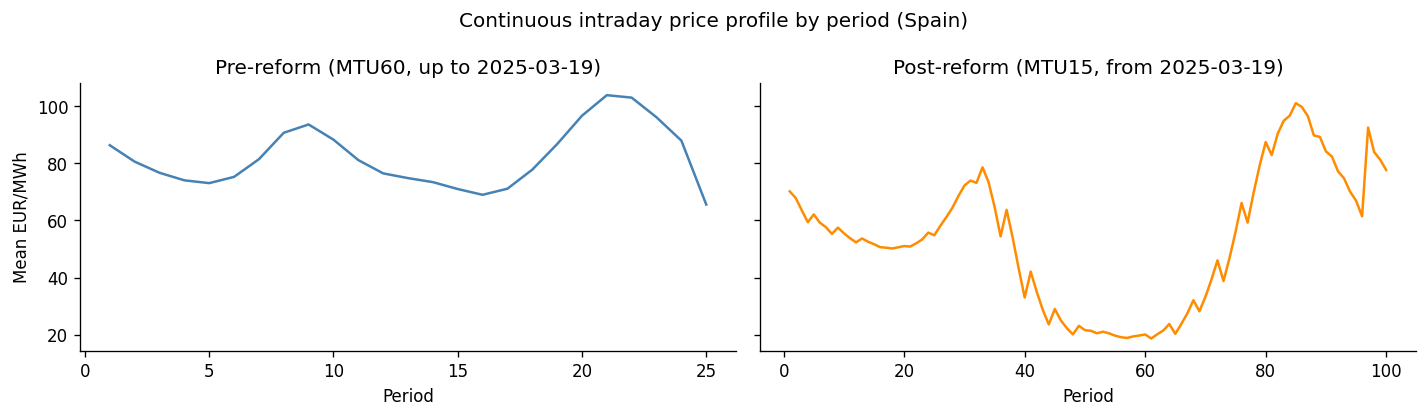

In [434]:
PRECIOS_PIBCIC_RONDA = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_continuo/precios/precios_pibcic_ronda_all.parquet"

df_cont = pd.read_parquet(PRECIOS_PIBCIC_RONDA)
df_cont["date"] = pd.to_datetime(df_cont["date"])
print(f"precios_pibcic_ronda: {len(df_cont):,} rows, {df_cont['date'].min().date()} → {df_cont['date'].max().date()}")
print(f"MTU breakdown: {df_cont.groupby('mtu_minutes')['date'].nunique().to_dict()} days")

# Aggregate across rounds: mean price per (date, period). Rounds are intra-day snapshots of the same delivery period.
period_price = df_cont.groupby(["date", "period", "mtu_minutes"])["price_mean_es_eur_mwh"].mean().reset_index()

pre_cont  = period_price[period_price["date"] <  INTRADAY_REFORM]
post_cont = period_price[period_price["date"] >= INTRADAY_REFORM]

pre_profile  = pre_cont.groupby("period")["price_mean_es_eur_mwh"].mean()
post_profile = post_cont.groupby("period")["price_mean_es_eur_mwh"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
axes[0].plot(pre_profile.index,  pre_profile.values,  linewidth=1.5, color="steelblue")
axes[0].set_title(f"Pre-reform (MTU60, up to {INTRADAY_REFORM.date()})")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Mean EUR/MWh")

axes[1].plot(post_profile.index, post_profile.values, linewidth=1.5, color="darkorange")
axes[1].set_title(f"Post-reform (MTU15, from {INTRADAY_REFORM.date()})")
axes[1].set_xlabel("Period")

plt.suptitle("Continuous intraday price profile by period (Spain)", fontsize=12)
plt.tight_layout()
plt.show()

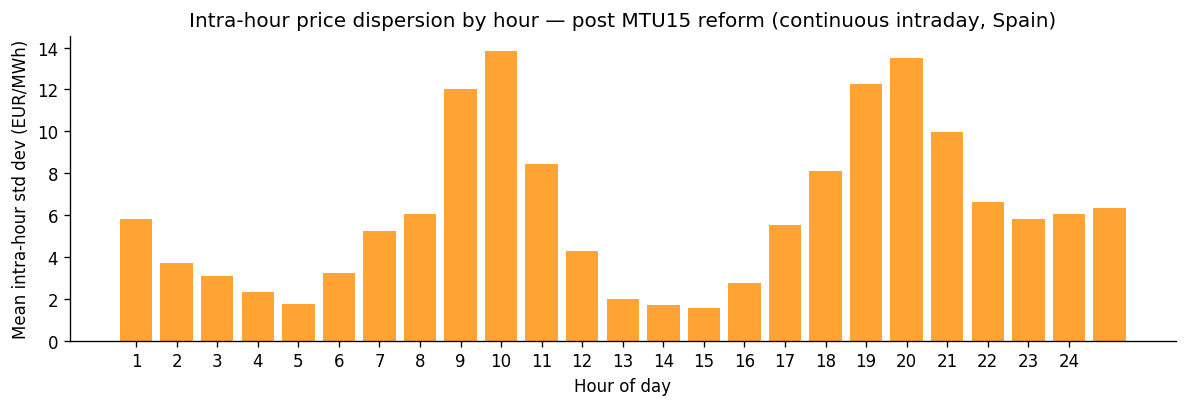

Overall mean intra-hour std dev: 6.08 EUR/MWh
Max (hour 10): 13.86 EUR/MWh


In [435]:
post_mtu15_cont = period_price[(period_price["date"] >= INTRADAY_REFORM) & (period_price["mtu_minutes"] == 15)].copy()
post_mtu15_cont["hour"] = ((post_mtu15_cont["period"] - 1) // 4) + 1

intra_hour_std_cont = (
    post_mtu15_cont.groupby(["date", "hour"])["price_mean_es_eur_mwh"]
    .std()
    .reset_index()
    .groupby("hour")["price_mean_es_eur_mwh"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(intra_hour_std_cont.index, intra_hour_std_cont.values, color="darkorange", alpha=0.8)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean intra-hour std dev (EUR/MWh)")
ax.set_title("Intra-hour price dispersion by hour — post MTU15 reform (continuous intraday, Spain)")
ax.set_xticks(range(1, 25))
plt.tight_layout()
plt.show()

print(f"Overall mean intra-hour std dev: {intra_hour_std_cont.mean():.2f} EUR/MWh")
print(f"Max (hour {intra_hour_std_cont.idxmax()}): {intra_hour_std_cont.max():.2f} EUR/MWh")

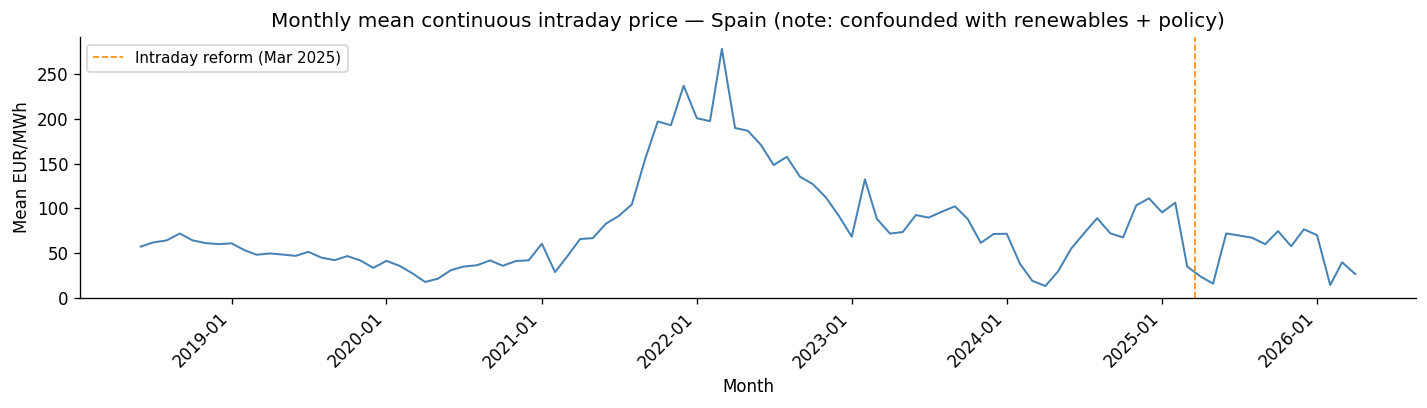

In [436]:
monthly_cont = (
    period_price.groupby(period_price["date"].dt.to_period("M"))["price_mean_es_eur_mwh"]
    .mean()
    .reset_index()
)
monthly_cont["date"] = monthly_cont["date"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(monthly_cont["date"], monthly_cont["price_mean_es_eur_mwh"], linewidth=1.2, color="steelblue")
ax.axvline(INTRADAY_REFORM, color="darkorange", linestyle="--", linewidth=1, label="Intraday reform (Mar 2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Mean EUR/MWh")
ax.set_title("Monthly mean continuous intraday price — Spain (note: confounded with renewables + policy)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## Section 5 — Continuous intraday matched power (`pibcic`)

Data: `pibcic` — assigned power (MW) per unit, round, and delivery period in the continuous intraday market.
Each row is a `(date, round_number, period, unit_code)` triplet with `assigned_power_mw` (positive = buy, negative = sell).

Coverage: **2018-06-13 → 2026-01-10** · 66,134 files · 2,474 MTU60 days + 297 MTU15 days

In [437]:
PIBCIC = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_continuo/programas/pibcic_all.parquet"

df_pibcic = pd.read_parquet(PIBCIC)
df_pibcic["date"] = pd.to_datetime(df_pibcic["date"])
print(f"pibcic: {len(df_pibcic):,} rows, {df_pibcic['date'].min().date()} → {df_pibcic['date'].max().date()}")
print(f"MTU breakdown: {df_pibcic.groupby('mtu_minutes')['date'].nunique().to_dict()} days")
print(f"Unique units:  {df_pibcic['unit_code'].nunique()}")
print(f"Round range:   {df_pibcic['round_number'].min()} – {df_pibcic['round_number'].max()}")

pibcic: 11,795,924 rows, 2018-06-13 → 2026-01-10
MTU breakdown: {15: 297, 60: 2474} days
Unique units:  2862
Round range:   1 – 25


### 5a. Daily matched volume and round activity over time

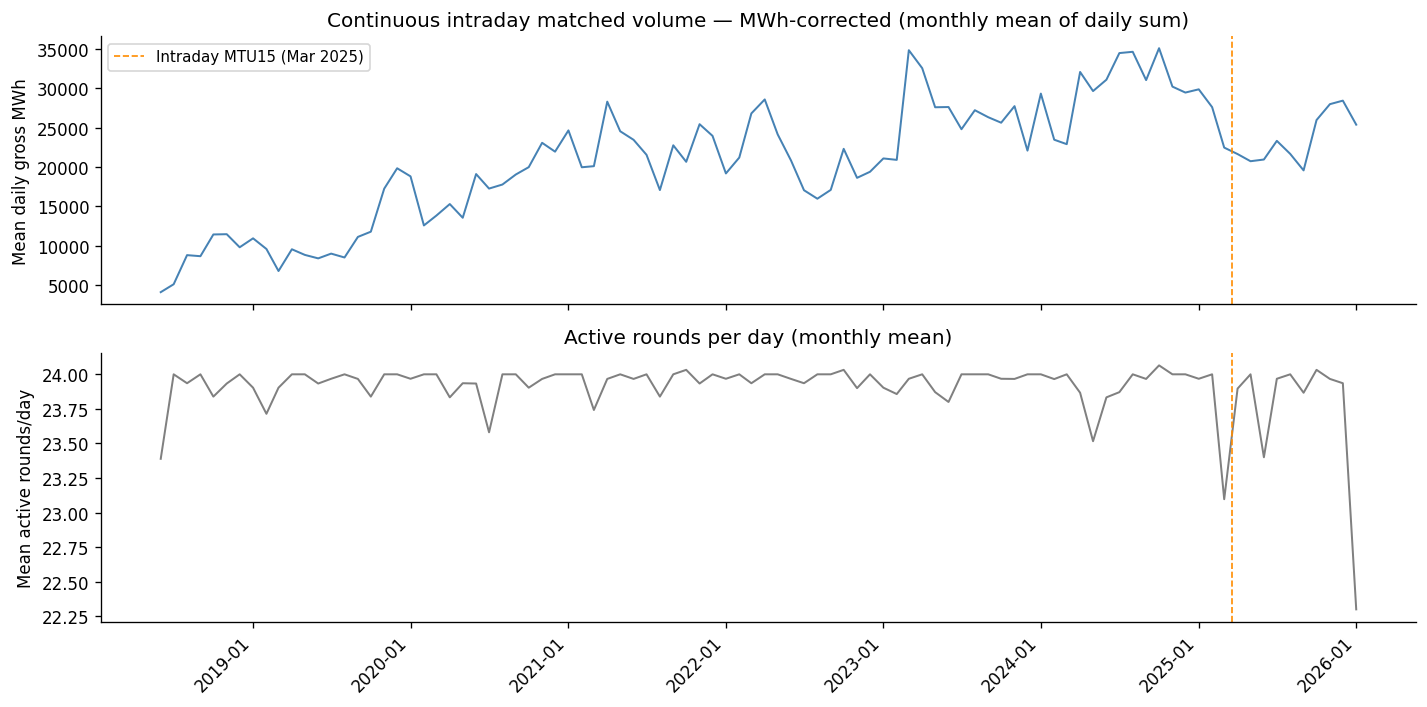

Mean daily gross MWh and active rounds by regime:
  Pre-MTU15  (< 2025-03-19): gross_mwh=20,708  active_rounds=23.9  (n=2471 days)
  Post-MTU15 (≥ 2025-03-19): gross_mwh=23,134  active_rounds=23.8  (n=297 days)


In [438]:
# MWh-corrected volume: |MW| × (mtu_minutes/60) removes the mechanical 4× inflation
# from having 96 periods/day post-reform instead of 24 pre-reform.
df_pibcic["gross_mwh"] = df_pibcic["assigned_power_mw"].abs() * df_pibcic["mtu_minutes"] / 60

daily = df_pibcic.groupby("date").agg(
    gross_mwh=("gross_mwh", "sum"),
    active_rounds=("round_number", "nunique"),
).reset_index()

monthly_pibcic = daily.groupby(daily["date"].dt.to_period("M")).agg(
    gross_mwh=("gross_mwh", "mean"),
    active_rounds=("active_rounds", "mean"),
).reset_index()
monthly_pibcic["date"] = monthly_pibcic["date"].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(monthly_pibcic["date"], monthly_pibcic["gross_mwh"], linewidth=1.2, color="steelblue")
axes[0].axvline(INTRADAY_REFORM, color="darkorange", linestyle="--", linewidth=1, label="Intraday MTU15 (Mar 2025)")
axes[0].set_ylabel("Mean daily gross MWh")
axes[0].set_title("Continuous intraday matched volume — MWh-corrected (monthly mean of daily sum)")
axes[0].legend(fontsize=9)

axes[1].plot(monthly_pibcic["date"], monthly_pibcic["active_rounds"], linewidth=1.2, color="gray")
axes[1].axvline(INTRADAY_REFORM, color="darkorange", linestyle="--", linewidth=1)
axes[1].set_ylabel("Mean active rounds/day")
axes[1].set_title("Active rounds per day (monthly mean)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Mean daily gross MWh and active rounds by regime:")
for label, mask in [
    ("Pre-MTU15  (< 2025-03-19)", daily["date"] < INTRADAY_REFORM),
    ("Post-MTU15 (≥ 2025-03-19)", daily["date"] >= INTRADAY_REFORM),
]:
    sub = daily[mask]
    print(f"  {label}: gross_mwh={sub['gross_mwh'].mean():,.0f}  active_rounds={sub['active_rounds'].mean():.1f}  (n={len(sub)} days)")


### 5a-bis. Raw MW-sum vs MWh — showing the mechanical effect

The raw MW-sum doubles at the MTU15 reform purely because there are 4× more period rows per day.
The MWh-corrected series (shown in 5a) removes this inflation.
This cell shows both side by side to make the mechanical artefact explicit.


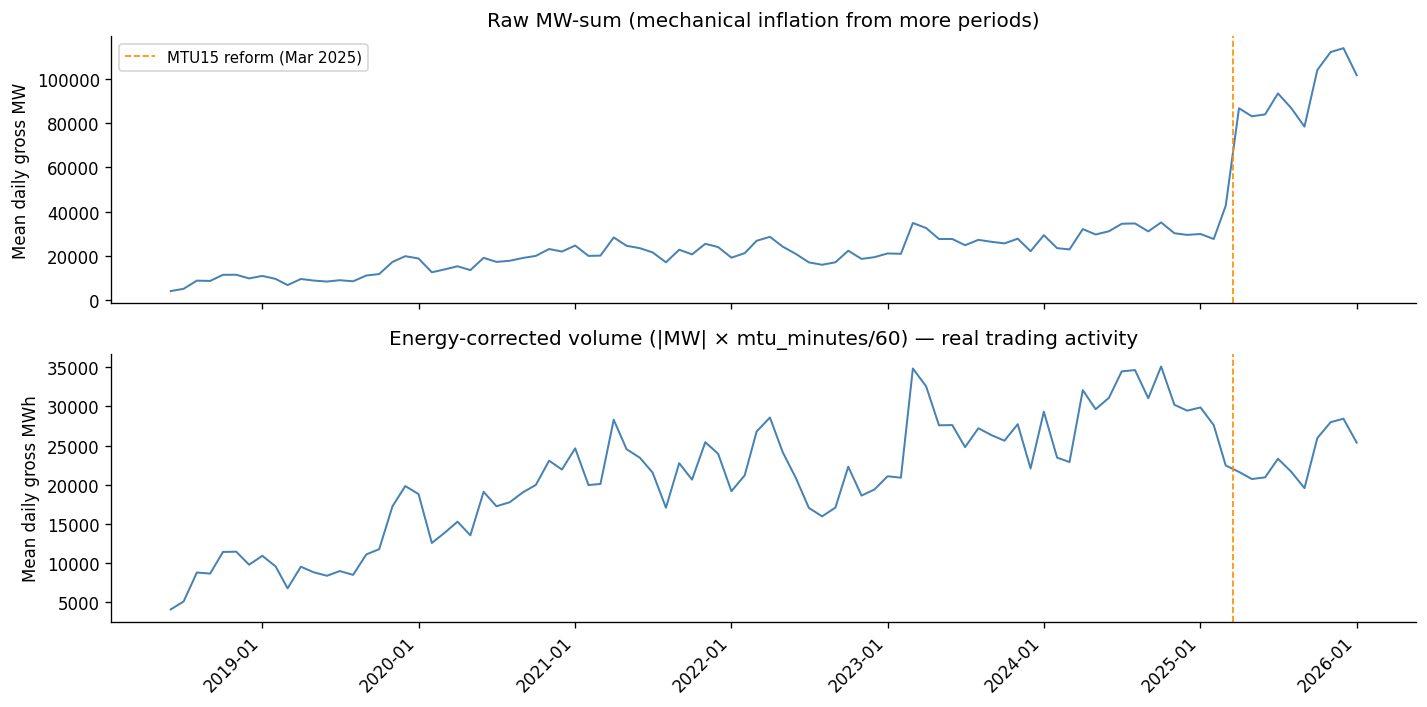

Regime                             Gross MW    Gross MWh   Days
----------------------------------------------------------------
Pre-MTU15  (< 2025-03-19)            20,708       20,708   2471
Post-MTU15 (≥ 2025-03-19)            92,534       23,134    297

Post/pre ratio — MW-sum: 4.47x   MWh: 1.12x
(If MWh ratio ≈ MW ratio: break is real. If MWh ratio ≈ 1: purely mechanical.)


In [439]:
# Energy-equivalent: MWh = |MW| × (mtu_minutes / 60)
df_pibcic["gross_mwh"] = df_pibcic["assigned_power_mw"].abs() * df_pibcic["mtu_minutes"] / 60

daily_energy = df_pibcic.groupby("date").agg(
    gross_mw=("assigned_power_mw", lambda x: x.abs().sum()),
    gross_mwh=("gross_mwh", "sum"),
).reset_index()

monthly_energy = daily_energy.groupby(daily_energy["date"].dt.to_period("M")).agg(
    gross_mw=("gross_mw", "mean"),
    gross_mwh=("gross_mwh", "mean"),
).reset_index()
monthly_energy["date"] = monthly_energy["date"].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(monthly_energy["date"], monthly_energy["gross_mw"], linewidth=1.2, color="steelblue")
axes[0].axvline(INTRADAY_REFORM, color="darkorange", linestyle="--", linewidth=1, label="MTU15 reform (Mar 2025)")
axes[0].set_ylabel("Mean daily gross MW")
axes[0].set_title("Raw MW-sum (mechanical inflation from more periods)")
axes[0].legend(fontsize=9)

axes[1].plot(monthly_energy["date"], monthly_energy["gross_mwh"], linewidth=1.2, color="steelblue")
axes[1].axvline(INTRADAY_REFORM, color="darkorange", linestyle="--", linewidth=1)
axes[1].set_ylabel("Mean daily gross MWh")
axes[1].set_title("Energy-corrected volume (|MW| × mtu_minutes/60) — real trading activity")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Regime means
print(f"{'Regime':<30} {'Gross MW':>12} {'Gross MWh':>12} {'Days':>6}")
print("-" * 64)
for label, mask in [
    ("Pre-MTU15  (< 2025-03-19)", daily_energy["date"] < INTRADAY_REFORM),
    ("Post-MTU15 (≥ 2025-03-19)", daily_energy["date"] >= INTRADAY_REFORM),
]:
    sub = daily_energy[mask]
    print(f"{label:<30} {sub['gross_mw'].mean():>12,.0f} {sub['gross_mwh'].mean():>12,.0f} {len(sub):>6}")

ratio_mw  = daily_energy[daily_energy["date"] >= INTRADAY_REFORM]["gross_mw"].mean()  / daily_energy[daily_energy["date"] < INTRADAY_REFORM]["gross_mw"].mean()
ratio_mwh = daily_energy[daily_energy["date"] >= INTRADAY_REFORM]["gross_mwh"].mean() / daily_energy[daily_energy["date"] < INTRADAY_REFORM]["gross_mwh"].mean()
print(f"\nPost/pre ratio — MW-sum: {ratio_mw:.2f}x   MWh: {ratio_mwh:.2f}x")
print(f"(If MWh ratio ≈ MW ratio: break is real. If MWh ratio ≈ 1: purely mechanical.)")

### 5b. Matched volume profile by period — pre vs post MTU15

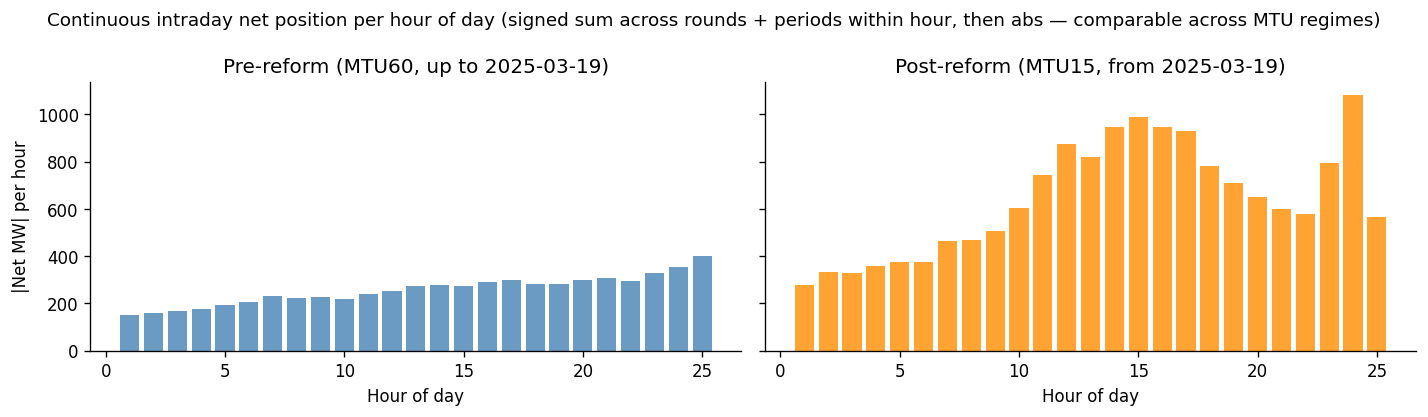

In [440]:
# Aggregate net position to hour-of-day for a fair pre/post comparison.
# Pre-reform: period == hour (1-24). Post-reform: hour = (period-1)//4 + 1.
# Within each (date, hour) sum signed MW across periods, then abs — avoids
# artificially inflating the post-reform profile by counting 4 periods vs 1.
net_period = df_pibcic.groupby(["date", "period"])["assigned_power_mw"].sum().reset_index(name="net_mw")

pre_df  = net_period[net_period["date"] < INTRADAY_REFORM].copy()
post_df = net_period[net_period["date"] >= INTRADAY_REFORM].copy()

pre_df["hour"]  = pre_df["period"]               # MTU60: period == hour
post_df["hour"] = (post_df["period"] - 1) // 4 + 1  # MTU15: 4 periods per hour

# Sum signed MW within each (date, hour), then abs
pre_hourly  = pre_df.groupby(["date", "hour"])["net_mw"].sum().abs().groupby("hour").mean()
post_hourly = post_df.groupby(["date", "hour"])["net_mw"].sum().abs().groupby("hour").mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
axes[0].bar(pre_hourly.index,  pre_hourly.values,  color="steelblue",  alpha=0.8)
axes[0].set_title(f"Pre-reform (MTU60, up to {INTRADAY_REFORM.date()})")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("|Net MW| per hour")

axes[1].bar(post_hourly.index, post_hourly.values, color="darkorange", alpha=0.8)
axes[1].set_title(f"Post-reform (MTU15, from {INTRADAY_REFORM.date()})")
axes[1].set_xlabel("Hour of day")

plt.suptitle("Continuous intraday net position per hour of day (signed sum across rounds + periods within hour, then abs — comparable across MTU regimes)", fontsize=11)
plt.tight_layout()
plt.show()


### 5c. Intra-hour volume dispersion — post MTU15

Post-reform, each hour has 4 quarter-hour delivery periods. This shows whether matched volume
is spread evenly within the hour or concentrated in specific quarters.

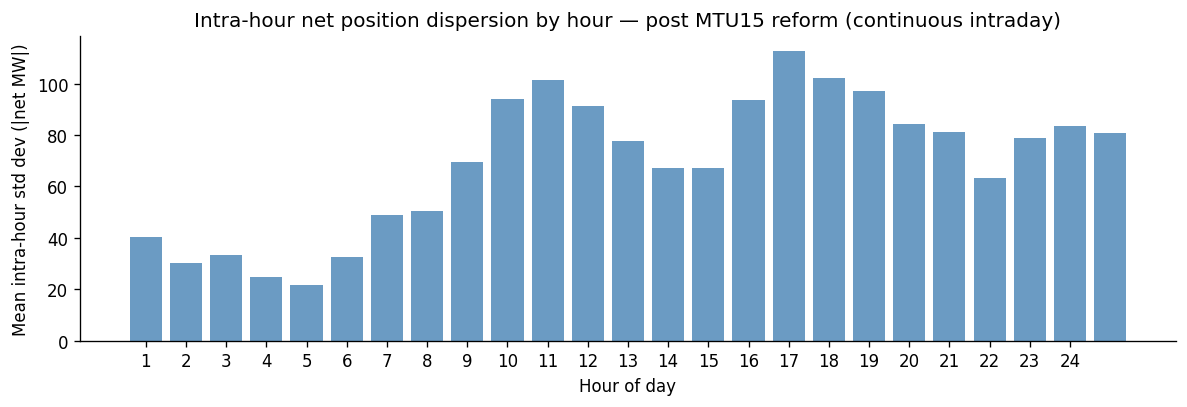

Overall mean intra-hour std dev: 69.1 MW
Max (hour 17): 112.9 MW


In [441]:
post_mtu15_net = net_period[
    (net_period["date"] >= INTRADAY_REFORM) &
    (net_period["date"].isin(df_pibcic[df_pibcic["mtu_minutes"] == 15]["date"].unique()))
].copy()
post_mtu15_net["abs_net_mw"] = post_mtu15_net["net_mw"].abs()
post_mtu15_net["hour"] = ((post_mtu15_net["period"] - 1) // 4) + 1

intra_hour_std_net = (
    post_mtu15_net.groupby(["date", "hour"])["abs_net_mw"]
    .std()
    .reset_index()
    .groupby("hour")["abs_net_mw"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(intra_hour_std_net.index, intra_hour_std_net.values, color="steelblue", alpha=0.8)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean intra-hour std dev (|net MW|)")
ax.set_title("Intra-hour net position dispersion by hour — post MTU15 reform (continuous intraday)")
ax.set_xticks(range(1, 25))
plt.tight_layout()
plt.show()

print(f"Overall mean intra-hour std dev: {intra_hour_std_net.mean():.1f} MW")
print(f"Max (hour {intra_hour_std_net.idxmax()}): {intra_hour_std_net.max():.1f} MW")


### 5d. Round-level activity — matched MW per round, pre vs post MTU15

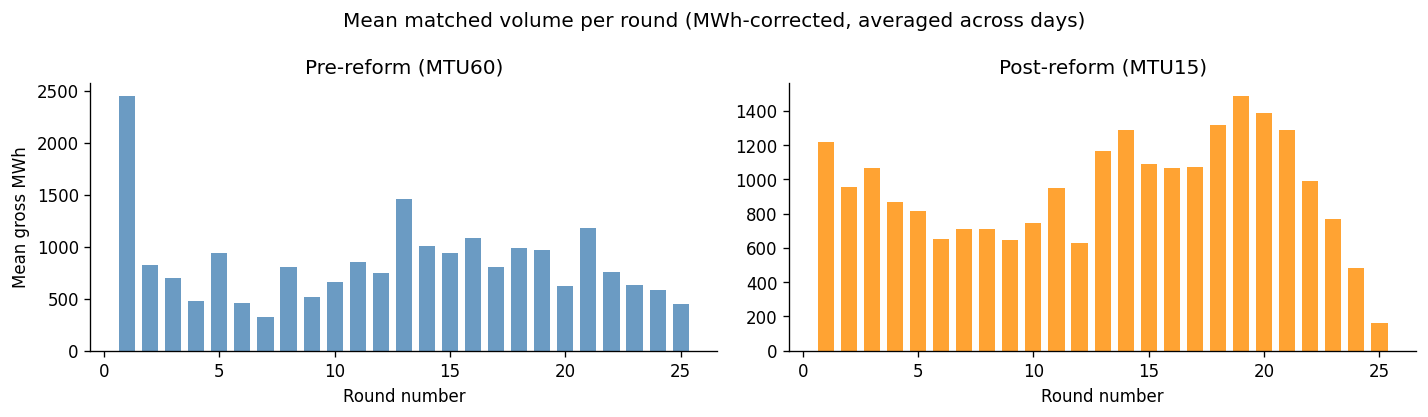

Top 5 rounds by mean matched MWh (pre-reform):
round_number
1     2450.406458
13    1457.179029
21    1176.774818
16    1085.783043
14    1006.489273

Top 5 rounds by mean matched MWh (post-reform):
round_number
19    1486.852778
20    1383.965741
18    1318.170118
14    1289.801627
21    1286.801431


In [442]:
# Round-level matched volume in MWh (|MW| × mtu_minutes/60).
# Using MWh corrects for the 4× more periods per round post-reform.
df_pibcic["gross_mwh"] = df_pibcic["assigned_power_mw"].abs() * df_pibcic["mtu_minutes"] / 60

round_vol = df_pibcic.groupby(["date", "round_number"])["gross_mwh"].sum().reset_index(name="gross_mwh")

pre_round  = round_vol[round_vol["date"] < INTRADAY_REFORM].groupby("round_number")["gross_mwh"].mean()
post_round = round_vol[round_vol["date"] >= INTRADAY_REFORM].groupby("round_number")["gross_mwh"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].bar(pre_round.index,  pre_round.values,  color="steelblue",  alpha=0.8, width=0.7)
axes[0].set_title("Pre-reform (MTU60)")
axes[0].set_xlabel("Round number")
axes[0].set_ylabel("Mean gross MWh")

axes[1].bar(post_round.index, post_round.values, color="darkorange", alpha=0.8, width=0.7)
axes[1].set_title("Post-reform (MTU15)")
axes[1].set_xlabel("Round number")

plt.suptitle("Mean matched volume per round (MWh-corrected, averaged across days)", fontsize=12)
plt.tight_layout()
plt.show()

print("Top 5 rounds by mean matched MWh (pre-reform):")
print(pre_round.nlargest(5).to_string())
print()
print("Top 5 rounds by mean matched MWh (post-reform):")
print(post_round.nlargest(5).to_string())


---
## Section 6 — Continuous intraday accumulated programs (`pibcac`)

Data: `pibcac_all.parquet` — cumulative scheduled MW per unit after each round of the continuous market.
Unlike PIBCIC (incremental per round), each PIBCAC file contains the full accumulated position for every unit × period after that round.

**2.7 billion rows** — 59,299 files, 2018-06-13 → 2026-01-10.

> **Data availability gap**: OMIE ZIP archives for 2025-04 through 2025-12 return HTTP 500 — those months
> are not publicly available. Post-reform coverage is limited to 2025-03-19 → 2025-03-31 (13 days) and
> 2026-01-01 → 2026-01-10 (10 days). Cross-regime comparisons in this section should be interpreted
> with caution given the very small post-reform sample.

> **Interpretive caveat**: PIBCAC records only *matched* power — accepted offers. Rejected offers are not observed.
> Total matched volume is bounded by system demand, so changes in matched volume may reflect demand shifts
> rather than changes in market activity. We cannot use this data alone to conclude whether the MTU15 reform
> increased or decreased trading activity. What we can study is the *shape* of the schedule: which hours
> are most traded, how the position builds across rounds, and how the intraday profile compares across regimes.

In [443]:
PIBCAC = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_continuo/programas/pibcac_all.parquet"

# Load via DuckDB — too large for full in-memory pandas
con_ac = duckdb.connect()

# Sample check
info = con_ac.execute(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT date) AS n_days,
        MIN(date) AS date_min,
        MAX(date) AS date_max,
        COUNT(DISTINCT unit_code) AS n_units
    FROM read_parquet('{PIBCAC}')
""").fetchone()
print(f"Rows: {info[0]:,}  Days: {info[1]}  Range: {info[2]} -> {info[3]}  Units: {info[4]}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 2,691,641,468  Days: 2480  Range: 2018-06-13 -> 2026-01-10  Units: 5567


### 6a. Daily last-round accumulated volume over time

For each day, take the **last round** (highest round_number) as the final settled state.
Sum absolute MW across all units and periods to get total accumulated volume.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

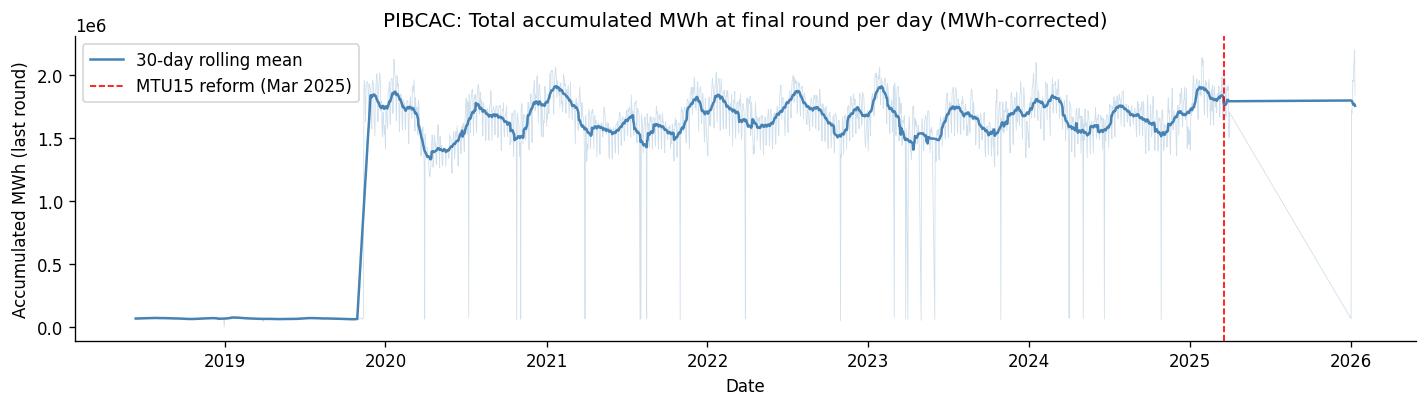

Pre-reform mean:  1,327,853 MWh
Post-reform mean: 1,795,048 MWh
Ratio (post/pre): 1.35x
(Ratio ~1 = no change in matched energy; MWh corrects for extra periods post-reform)


In [444]:
# MWh-corrected: multiply |MW| by mtu_minutes/60 to remove the mechanical 4× inflation
# from 96 periods/day (MTU15) vs 24 (MTU60).
daily_last = con_ac.execute(f"""
    WITH last_round AS (
        SELECT date, MAX(round_number) AS last_round
        FROM read_parquet('{PIBCAC}')
        GROUP BY date
    )
    SELECT p.date,
           SUM(ABS(p.assigned_power_mw) * p.mtu_minutes / 60.0) AS total_mwh
    FROM read_parquet('{PIBCAC}') p
    JOIN last_round l ON p.date = l.date AND p.round_number = l.last_round
    GROUP BY p.date
    ORDER BY p.date
""").df()

daily_last["date"] = pd.to_datetime(daily_last["date"])
daily_last["smoothed"] = daily_last["total_mwh"].rolling(30, center=True, min_periods=7).mean()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(daily_last["date"], daily_last["total_mwh"], alpha=0.25, color="steelblue", linewidth=0.5)
ax.plot(daily_last["date"], daily_last["smoothed"], color="steelblue", linewidth=1.5, label="30-day rolling mean")
ax.axvline(INTRADAY_REFORM, color="red", linestyle="--", linewidth=1, label="MTU15 reform (Mar 2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Accumulated MWh (last round)")
ax.set_title("PIBCAC: Total accumulated MWh at final round per day (MWh-corrected)")
ax.legend()
plt.tight_layout()
plt.show()

pre_mean  = daily_last.loc[daily_last["date"] < INTRADAY_REFORM, "total_mwh"].mean()
post_mean = daily_last.loc[daily_last["date"] >= INTRADAY_REFORM, "total_mwh"].mean()
print(f"Pre-reform mean:  {pre_mean:,.0f} MWh")
print(f"Post-reform mean: {post_mean:,.0f} MWh")
print(f"Ratio (post/pre): {post_mean/pre_mean:.2f}x")
print("(Ratio ~1 = no change in matched energy; MWh corrects for extra periods post-reform)")


### 6b. Accumulated position profile by hour of day — pre vs post MTU15

Mean accumulated MW per hour of day at the final round, averaged across days.
Both regimes mapped to hours 1–24: MTU60 directly (period = hour), MTU15 by averaging
the 4 quarter-hour periods within each hour.
This allows a direct shape comparison across regimes.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

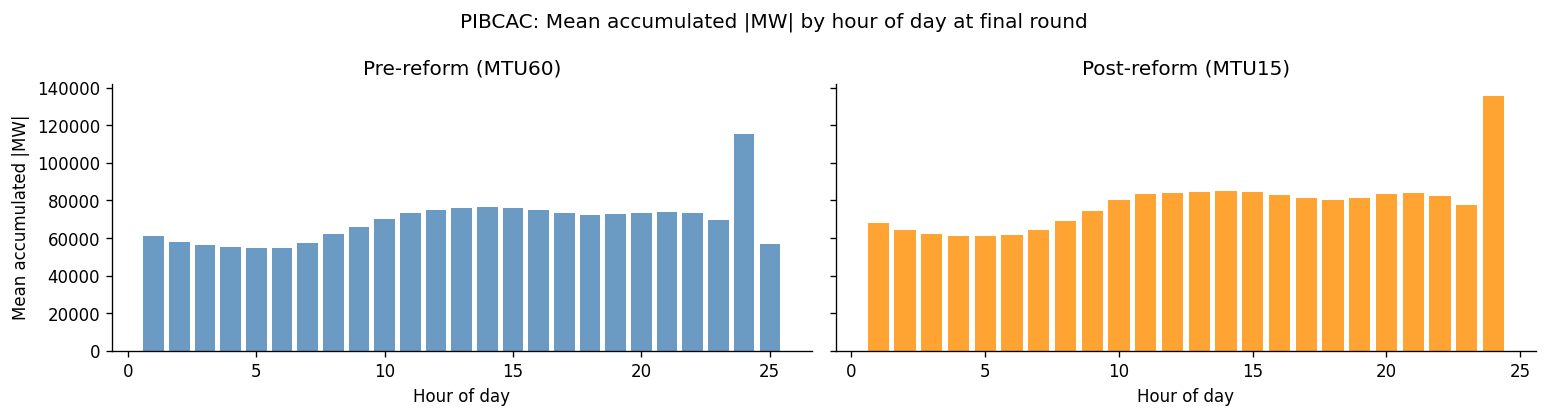

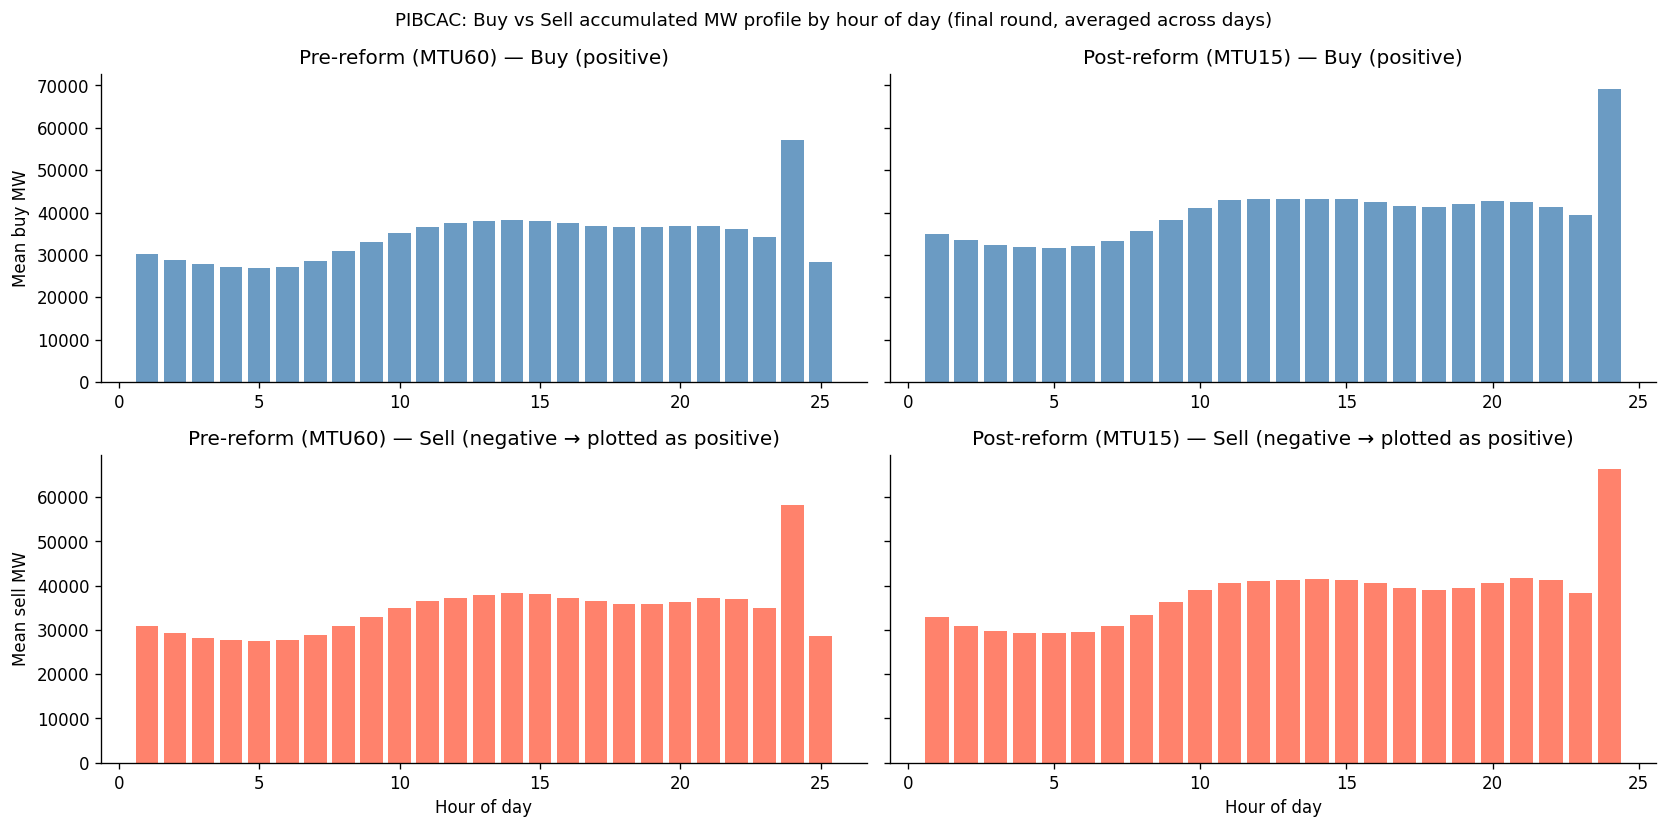

In [445]:
period_profile = con_ac.execute(f"""
    WITH last_round AS (
        SELECT date, MAX(round_number) AS last_round
        FROM read_parquet('{PIBCAC}')
        GROUP BY date
    )
    SELECT p.date, p.period, p.mtu_minutes,
           SUM(CASE WHEN p.assigned_power_mw > 0 THEN  p.assigned_power_mw ELSE 0 END) AS buy_mw,
           SUM(CASE WHEN p.assigned_power_mw < 0 THEN -p.assigned_power_mw ELSE 0 END) AS sell_mw,
           SUM(ABS(p.assigned_power_mw)) AS abs_mw
    FROM read_parquet('{PIBCAC}') p
    JOIN last_round l ON p.date = l.date AND p.round_number = l.last_round
    GROUP BY p.date, p.period, p.mtu_minutes
    ORDER BY p.date, p.period
""").df()

period_profile["date"] = pd.to_datetime(period_profile["date"])

# Map period → hour: MTU60 period==hour; MTU15 hour = (period-1)//4 + 1
period_profile["hour"] = period_profile.apply(
    lambda r: int(r["period"]) if r["mtu_minutes"] == 60 else (int(r["period"]) - 1) // 4 + 1,
    axis=1
)

pre_df  = period_profile[period_profile["date"] < INTRADAY_REFORM]
post_df = period_profile[period_profile["date"] >= INTRADAY_REFORM]

def hourly_mean(df, col):
    return df.groupby(["date", "hour"])[col].mean().groupby("hour").mean()

pre_buy   = hourly_mean(pre_df,  "buy_mw")
pre_sell  = hourly_mean(pre_df,  "sell_mw")
post_buy  = hourly_mean(post_df, "buy_mw")
post_sell = hourly_mean(post_df, "sell_mw")
pre_abs   = hourly_mean(pre_df,  "abs_mw")
post_abs  = hourly_mean(post_df, "abs_mw")

# ── Plot: |MW| profile pre/post (original) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)
axes[0].bar(pre_abs.index,  pre_abs.values,  color="steelblue",  alpha=0.8)
axes[0].set_title("Pre-reform (MTU60)")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Mean accumulated |MW|")
axes[1].bar(post_abs.index, post_abs.values, color="darkorange", alpha=0.8)
axes[1].set_title("Post-reform (MTU15)")
axes[1].set_xlabel("Hour of day")
plt.suptitle("PIBCAC: Mean accumulated |MW| by hour of day at final round", fontsize=12)
plt.tight_layout()
plt.show()

# ── Plot: buy vs sell profile pre/post ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey="row")
width = 0.4

for col_idx, (regime, buy, sell, label) in enumerate([
    ("Pre-reform (MTU60)",  pre_buy,  pre_sell,  f"up to {INTRADAY_REFORM.date()}"),
    ("Post-reform (MTU15)", post_buy, post_sell, f"from {INTRADAY_REFORM.date()}"),
]):
    ax_buy  = axes[0][col_idx]
    ax_sell = axes[1][col_idx]
    ax_buy.bar(buy.index,  buy.values,  color="steelblue", alpha=0.8, width=0.8)
    ax_sell.bar(sell.index, sell.values, color="tomato",    alpha=0.8, width=0.8)
    ax_buy.set_title(f"{regime} — Buy (positive)")
    ax_sell.set_title(f"{regime} — Sell (negative → plotted as positive)")
    ax_sell.set_xlabel("Hour of day")
    if col_idx == 0:
        axes[0][0].set_ylabel("Mean buy MW")
        axes[1][0].set_ylabel("Mean sell MW")

plt.suptitle("PIBCAC: Buy vs Sell accumulated MW profile by hour of day (final round, averaged across days)", fontsize=11)
plt.tight_layout()
plt.show()


### 6c. Round-by-round accumulation — how does the schedule build up?

For a representative recent pre-reform day, plot total accumulated |MW| after each round.

**Note on the x-axis:** The pibcac filename encodes a 2-digit sequential round number
(`pibcac_YYYYMMDDNN.V`). On average there are ~21 rounds per day, so the x-axis typically
runs from 1 to ~21. This is **not** the delivery period — it is the snapshot index.

**Note on the shape:** The accumulated |MW| is *not* monotonically increasing because
participants can cancel or partially reduce their continuous-market positions between rounds.
The common pattern is a gradual reduction in early rounds (net cancellations) followed by
a sharp spike in the final rounds as end-of-day rebalancing activity concentrates just
before the delivery window closes.


Sample day: 2025-03-18 (24 rounds)


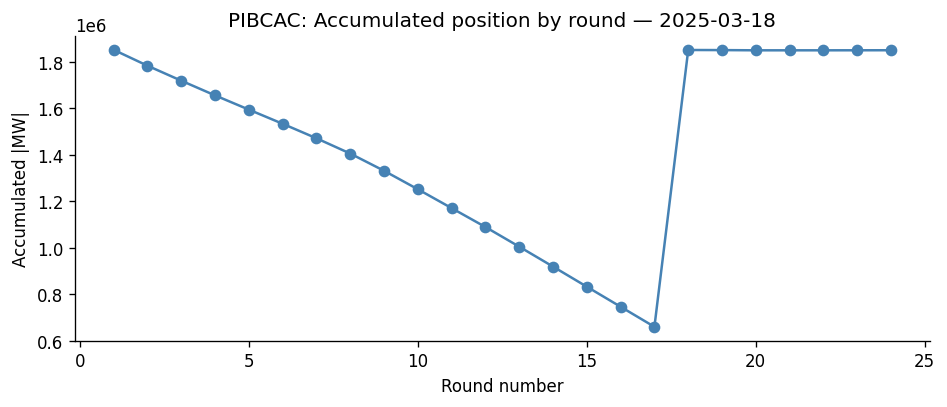

In [446]:
# Pick the most recent day with the most rounds
sample_day_row = con_ac.execute(f"""
    SELECT date, MAX(round_number) AS n_rounds
    FROM read_parquet('{PIBCAC}')
    WHERE date >= '{(INTRADAY_REFORM - pd.Timedelta(days=90)).date()}'
      AND date < '{INTRADAY_REFORM.date()}'
    GROUP BY date
    ORDER BY n_rounds DESC, date DESC
    LIMIT 1
""").fetchone()
sample_day = sample_day_row[0]
print(f"Sample day: {sample_day} ({sample_day_row[1]} rounds)")

round_accum = con_ac.execute(f"""
    SELECT round_number, SUM(ABS(assigned_power_mw)) AS total_abs_mw
    FROM read_parquet('{PIBCAC}')
    WHERE date = '{sample_day}'
    GROUP BY round_number
    ORDER BY round_number
""").df()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(round_accum["round_number"], round_accum["total_abs_mw"], marker="o", color="steelblue")
ax.set_xlabel("Round number")
ax.set_ylabel("Accumulated |MW|")
ax.set_title(f"PIBCAC: Accumulated position by round — {sample_day}")
plt.tight_layout()
plt.show()

---
## Section 7 — Day-ahead offers by technology (`cab` + `det` + `lista_unidades`)

Data: `det_all` (price/quantity per offer × period) joined to `cab_all` (offer headers with `unit_code`),
then mapped to technology via `lista_unidades`.

**Coverage:** 2018-01-01 → 2026-01-09 (all sell-side day-ahead offers).  
**MTU:** 60 min before 2025-10-01, 15 min from 2025-10-01 onward.  
**Note:** ~25 % of historical unit codes are not in the current `lista_unidades` (deactivated units)
and appear as **Other/Unknown**.  All volume figures use MWh-correction (MW × mtu_minutes/60)
to keep pre- and post-reform totals comparable.


In [447]:
CAB   = PROJECT_ROOT / "data/processed/omie/mercado_diario/ofertas/cab_all.parquet"
DET   = PROJECT_ROOT / "data/processed/omie/mercado_diario/ofertas/det_all.parquet"
UNITS = PROJECT_ROOT / "data/external/omie_reference/lista_unidades.csv"

con_det = duckdb.connect()

TECH_SQL = """CASE
        WHEN u.technology IN ('RE Mercado Solar Fotovoltáica', 'RE Mercado Solar Térmica') THEN 'Solar'
        WHEN u.technology = 'RE Mercado Eólica'                                             THEN 'Wind'
        WHEN u.technology IN ('RE Mercado Hidráulica', 'Hidráulica Generación')             THEN 'Hydro'
        WHEN u.technology = 'Ciclo Combinado'                                               THEN 'CCGT'
        WHEN u.technology = 'Nuclear'                                                       THEN 'Nuclear'
        WHEN u.technology = 'RE Mercado Térmica no Renovab.'                               THEN 'Thermal (non-RES)'
        WHEN u.technology = 'RE Mercado Térmica Renovable'                                 THEN 'Thermal (RES)'
        ELSE 'Other/Unknown'
    END"""

TECH_COLORS = {
    'Solar':             '#f4a41b',
    'Wind':              '#4a90d9',
    'Hydro':             '#1565c0',
    'CCGT':              '#e53935',
    'Nuclear':           '#8e24aa',
    'Thermal (non-RES)': '#795548',
    'Thermal (RES)':     '#43a047',
    'Other/Unknown':     '#bdbdbd',
}
TECH_ORDER = ['Nuclear', 'Hydro', 'CCGT', 'Thermal (non-RES)', 'Thermal (RES)', 'Wind', 'Solar', 'Other/Unknown']

# Quick coverage check (sell-side only)
cov = con_det.execute(f"""
    SELECT {TECH_SQL} AS tech_group,
           COUNT(DISTINCT c.unit_code) AS n_units,
           COUNT(DISTINCT c.date)      AS n_days,
           ROUND(SUM(1) / 1e3, 0)     AS n_offers_k
    FROM read_parquet('{CAB}') c
    LEFT JOIN read_csv('{UNITS}') u ON c.unit_code = u.unit_code
    WHERE c.buy_sell = 'V'
    GROUP BY 1 ORDER BY n_offers_k DESC
""").df()
print("Sell-side offer headers by technology:")
print(cov.to_string(index=False))


Sell-side offer headers by technology:
       tech_group  n_units  n_days  n_offers_k
    Other/Unknown     1389    3296      1168.0
            Solar     1214    3296       993.0
Thermal (non-RES)      365    3296       559.0
             Wind      392    3296       558.0
            Hydro      272    3296       461.0
    Thermal (RES)       95    3296       156.0
             CCGT       57    3296       154.0
          Nuclear        7    3296        48.0


### 7a. Sell-side offer volume by technology over time

Daily MWh offered per technology (sell side, MWh-corrected).
The stacked area shows the evolving technology mix.  
The vertical dashed line marks the day-ahead MTU15 reform (2025-10-01).

> **Runtime note:** full scan of 172 M det rows — expect ~2–3 min.


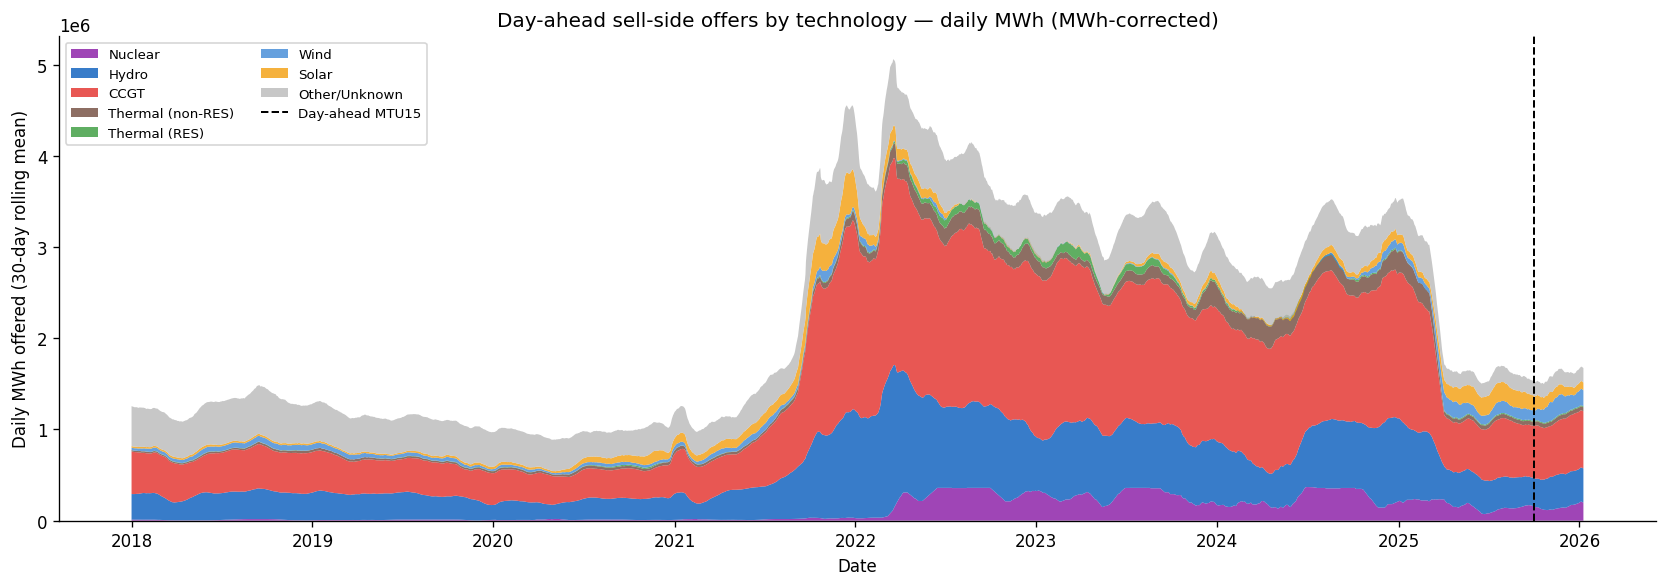

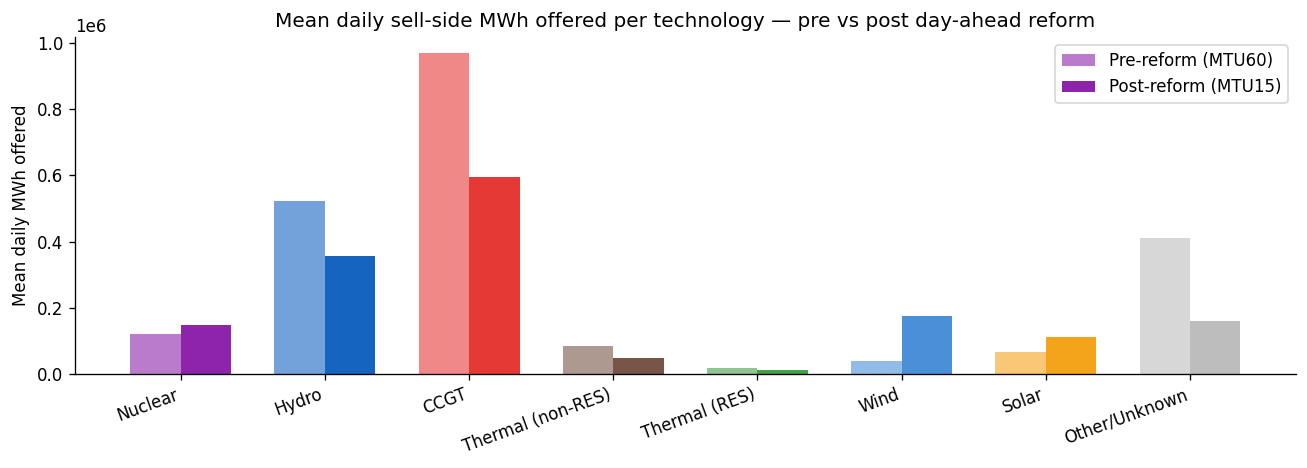

In [448]:
daily_tech = con_det.execute(f"""
    WITH base AS (
        SELECT d.date, d.quantity_mw, d.mtu_minutes, c.unit_code
        FROM read_parquet('{DET}') d
        JOIN read_parquet('{CAB}') c
          ON d.date = c.date AND d.offer_code = c.offer_code
        WHERE c.buy_sell = 'V'
    )
    SELECT b.date,
           CASE
        WHEN u.technology IN ('RE Mercado Solar Fotovoltáica', 'RE Mercado Solar Térmica') THEN 'Solar'
        WHEN u.technology = 'RE Mercado Eólica'                                             THEN 'Wind'
        WHEN u.technology IN ('RE Mercado Hidráulica', 'Hidráulica Generación')             THEN 'Hydro'
        WHEN u.technology = 'Ciclo Combinado'                                               THEN 'CCGT'
        WHEN u.technology = 'Nuclear'                                                       THEN 'Nuclear'
        WHEN u.technology = 'RE Mercado Térmica no Renovab.'                               THEN 'Thermal (non-RES)'
        WHEN u.technology = 'RE Mercado Térmica Renovable'                                 THEN 'Thermal (RES)'
        ELSE 'Other/Unknown'
    END AS tech_group,
           SUM(b.quantity_mw * b.mtu_minutes / 60.0) AS mwh
    FROM base b
    LEFT JOIN read_csv('{UNITS}') u ON b.unit_code = u.unit_code
    GROUP BY b.date, tech_group
    ORDER BY b.date, tech_group
""").df()

daily_tech["date"] = pd.to_datetime(daily_tech["date"])

# Pivot and smooth for stacked area chart
pivot = daily_tech.pivot_table(index="date", columns="tech_group", values="mwh", aggfunc="sum").fillna(0)
pivot = pivot[[c for c in TECH_ORDER if c in pivot.columns]]
pivot_smooth = pivot.rolling(30, center=True, min_periods=7).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(
    pivot_smooth.index,
    [pivot_smooth[c] for c in pivot_smooth.columns],
    labels=pivot_smooth.columns,
    colors=[TECH_COLORS[c] for c in pivot_smooth.columns],
    alpha=0.85,
)
ax.axvline(DAY_AHEAD_REFORM, color="black", linestyle="--", linewidth=1.2, label="Day-ahead MTU15")
ax.set_xlabel("Date")
ax.set_ylabel("Daily MWh offered (30-day rolling mean)")
ax.set_title("Day-ahead sell-side offers by technology — daily MWh (MWh-corrected)")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# Pre / post bar comparison (mean daily MWh per technology)
pre  = daily_tech[daily_tech["date"] <  DAY_AHEAD_REFORM].groupby("tech_group")["mwh"].mean()
post = daily_tech[daily_tech["date"] >= DAY_AHEAD_REFORM].groupby("tech_group")["mwh"].mean()
comp = pd.DataFrame({"Pre-reform (MTU60)": pre, "Post-reform (MTU15)": post}).reindex(TECH_ORDER).dropna(how="all")

fig, ax = plt.subplots(figsize=(11, 4))
x = range(len(comp))
w = 0.35
ax.bar([i - w/2 for i in x], comp["Pre-reform (MTU60)"], width=w, label="Pre-reform (MTU60)",
       color=[TECH_COLORS[t] for t in comp.index], alpha=0.6)
ax.bar([i + w/2 for i in x], comp["Post-reform (MTU15)"], width=w, label="Post-reform (MTU15)",
       color=[TECH_COLORS[t] for t in comp.index], alpha=1.0)
ax.set_xticks(list(x))
ax.set_xticklabels(comp.index, rotation=20, ha="right")
ax.set_ylabel("Mean daily MWh offered")
ax.set_title("Mean daily sell-side MWh offered per technology — pre vs post day-ahead reform")
ax.legend()
plt.tight_layout()
plt.show()


### 7b. Merit order: bid price distribution by technology

**Note on data availability:** The pre-reform DET format (57-char lines, before 2025-03-19)
does not contain bid prices — that field is always 0. OMIE started publishing unit-level
bid prices with the new 60-char format introduced on **2025-03-19** (same day as the intraday
reform). This is itself a transparency gain: individual bid prices were not publicly available
before the reform.

The analysis below covers only the period **from 2025-03-19 onward**, split at the
day-ahead MTU15 reform (2025-10-01) into two regimes:
- **Pre day-ahead reform (MTU60 bids)**: 2025-03-19 → 2025-09-30
- **Post day-ahead reform (MTU15 bids)**: 2025-10-01 →

Both regimes use the same new format, so price comparisons are valid.


       tech_group                        regime         p10        p50         p90  n_rows
             CCGT Post day-ahead reform (MTU15)   82.823113 116.301379  677.173489 1975480
             CCGT  Pre day-ahead reform (MTU60)   87.420828 125.727394  927.456528  861676
            Hydro Post day-ahead reform (MTU15)  -23.205904   1.314399  369.745367 3214189
            Hydro  Pre day-ahead reform (MTU60)  -22.715102   0.021207  373.525678 1559639
          Nuclear Post day-ahead reform (MTU15) -500.000000 -50.000000 2999.000000  152552
          Nuclear  Pre day-ahead reform (MTU60) -500.000000 -15.000000 2999.000000   80774
    Other/Unknown Post day-ahead reform (MTU15)  -29.133452  -0.000014  176.603949 1735349
    Other/Unknown  Pre day-ahead reform (MTU60)  -31.204260  -0.140511  139.019143 1073877
            Solar Post day-ahead reform (MTU15)  -31.000000 -14.286292    0.749394 4641351
            Solar  Pre day-ahead reform (MTU60)  -44.687579  -9.999770    1.017279 2659503

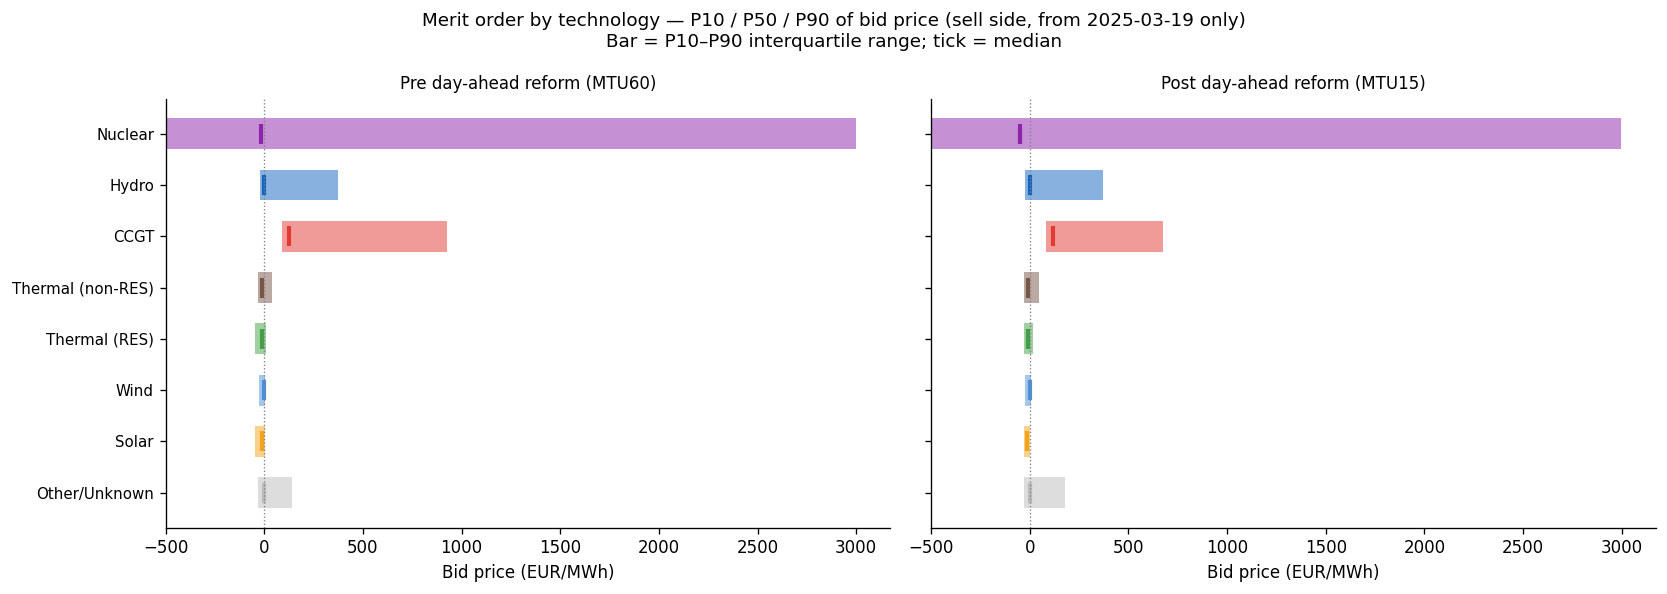

In [449]:
TECH_SQL = """CASE
        WHEN u.technology IN ('RE Mercado Solar Fotovoltáica', 'RE Mercado Solar Térmica') THEN 'Solar'
        WHEN u.technology = 'RE Mercado Eólica'                                             THEN 'Wind'
        WHEN u.technology IN ('RE Mercado Hidráulica', 'Hidráulica Generación')             THEN 'Hydro'
        WHEN u.technology = 'Ciclo Combinado'                                               THEN 'CCGT'
        WHEN u.technology = 'Nuclear'                                                       THEN 'Nuclear'
        WHEN u.technology = 'RE Mercado Térmica no Renovab.'                               THEN 'Thermal (non-RES)'
        WHEN u.technology = 'RE Mercado Térmica Renovable'                                 THEN 'Thermal (RES)'
        ELSE 'Other/Unknown'
    END"""

price_dist = con_det.execute(f"""
    WITH base AS (
        SELECT d.date, d.price_eur_mwh, d.quantity_mw, c.unit_code
        FROM read_parquet('{DET}') d
        JOIN read_parquet('{CAB}') c
          ON d.date = c.date AND d.offer_code = c.offer_code
        -- Only use data where OMIE publishes bid prices (new format from 2025-03-19)
        WHERE d.date >= '2025-03-19'
          AND c.buy_sell = 'V'
    )
    SELECT {TECH_SQL}                                              AS tech_group,
           CASE WHEN b.date < '{DAY_AHEAD_REFORM.date()}'
                THEN 'Pre day-ahead reform (MTU60)'
                ELSE 'Post day-ahead reform (MTU15)' END          AS regime,
           APPROX_QUANTILE(b.price_eur_mwh, 0.10)                AS p10,
           APPROX_QUANTILE(b.price_eur_mwh, 0.50)                AS p50,
           APPROX_QUANTILE(b.price_eur_mwh, 0.90)                AS p90,
           COUNT(*)                                               AS n_rows
    FROM base b
    LEFT JOIN read_csv('{UNITS}') u ON b.unit_code = u.unit_code
    GROUP BY tech_group, regime
    ORDER BY tech_group, regime
""").df()

print(price_dist.to_string(index=False))

regimes  = ["Pre day-ahead reform (MTU60)", "Post day-ahead reform (MTU15)"]
techs    = [t for t in TECH_ORDER if t in price_dist["tech_group"].values]
n_tech   = len(techs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for col_i, regime in enumerate(regimes):
    ax  = axes[col_i]
    sub = price_dist[price_dist["regime"] == regime].set_index("tech_group")
    for i, tech in enumerate(reversed(techs)):
        if tech not in sub.index:
            continue
        row   = sub.loc[tech]
        color = TECH_COLORS[tech]
        ax.barh(i, row["p90"] - row["p10"], left=row["p10"],
                height=0.6, color=color, alpha=0.5)
        ax.plot(row["p50"], i, marker="|", color=color, markersize=12, markeredgewidth=2.5)
    ax.set_yticks(list(range(n_tech)))
    ax.set_yticklabels(list(reversed(techs)), fontsize=9)
    ax.set_xlabel("Bid price (EUR/MWh)")
    ax.set_title(regime, fontsize=10)
    ax.axvline(0, color="grey", linewidth=0.8, linestyle=":")

fig.suptitle(
    "Merit order by technology — P10 / P50 / P90 of bid price (sell side, from 2025-03-19 only)\n"
    "Bar = P10–P90 interquartile range; tick = median",
    fontsize=11
)
plt.tight_layout()
plt.show()


### 7c. Within-day bid price variability by technology

**Does the reform enable finer price differentiation within the day?**

For each sell-side offer in a given day, we compute the quantity-weighted average bid price
per period, then take the standard deviation of those period-prices across the day.
A high std dev means the unit bids very differently at different times of day.

Uses 2025-03-19+ only (when DET started publishing bid prices). Compares:
- **Pre day-ahead reform (2025-03-19 to 2025-09-30)**: 24 hourly periods per day.
- **Post day-ahead reform (2025-10-01+)**: 96 fifteen-minute periods per day.  
  Only available if post-reform DET data has been synced.

- **Solar / Wind**: expected near-zero or negative-only bids — low std dev.
- **CCGT / Hydro**: flexible dispatchable units — expected higher std dev,
  as they vary price across peak / off-peak hours.

Within-day bid price variability by technology and regime:
       tech_group                        regime   mean_std   median_std  n_obs
             CCGT Post day-ahead reform (MTU15) 164.497436 1.079653e+02   4743
             CCGT  Pre day-ahead reform (MTU60) 189.710305 1.506546e+02   8894
            Hydro Post day-ahead reform (MTU15)   2.635822 0.000000e+00  18690
            Hydro  Pre day-ahead reform (MTU60)   3.015693 0.000000e+00  35954
          Nuclear Post day-ahead reform (MTU15)  21.097112 3.185955e-15   1364
          Nuclear  Pre day-ahead reform (MTU60)  38.303596 0.000000e+00   2565
    Other/Unknown Post day-ahead reform (MTU15)   2.617689 0.000000e+00  19699
    Other/Unknown  Pre day-ahead reform (MTU60)   2.666192 2.654561e-22  46498
            Solar Post day-ahead reform (MTU15)   1.208252 0.000000e+00 107558
            Solar  Pre day-ahead reform (MTU60)   1.403616 0.000000e+00 181842
    Thermal (RES) Post day-ahead reform (MTU15)   0.200578 0.000000e+00 

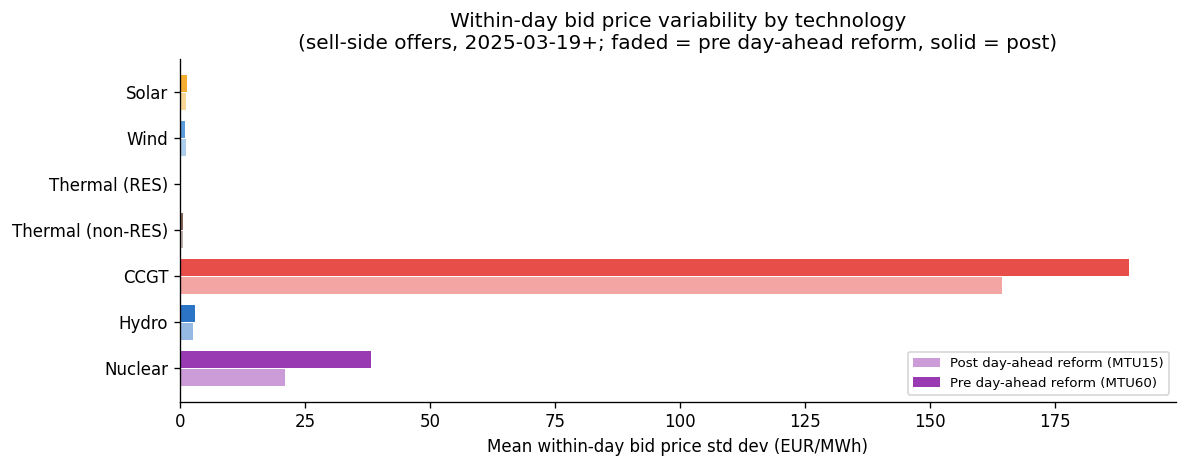

In [450]:
intra_day_std = con_det.execute(f"""
    WITH period_price AS (
        -- Quantity-weighted mean price per (date, offer_code, period)
        SELECT d.date, d.offer_code, d.period, c.unit_code,
               SUM(d.price_eur_mwh * ABS(d.quantity_mw))
                   / NULLIF(SUM(ABS(d.quantity_mw)), 0) AS wavg_price,
               CASE
                   WHEN d.date < '{DAY_AHEAD_REFORM.date()}'
                   THEN 'Pre day-ahead reform (MTU60)'
                   ELSE 'Post day-ahead reform (MTU15)'
               END AS regime
        FROM read_parquet('{DET}') d
        JOIN read_parquet('{CAB}') c
          ON d.date = c.date AND d.offer_code = c.offer_code
        WHERE d.date >= '2025-03-19'
          AND c.buy_sell = 'V'
        GROUP BY d.date, d.offer_code, d.period, c.unit_code, regime
    ),
    daily_std AS (
        SELECT date, offer_code, unit_code, regime,
               STDDEV(wavg_price) AS price_std
        FROM period_price
        GROUP BY date, offer_code, unit_code, regime
        HAVING COUNT(*) >= 4
    )
    SELECT {TECH_SQL} AS tech_group,
           regime,
           AVG(s.price_std)                   AS mean_std,
           APPROX_QUANTILE(s.price_std, 0.50) AS median_std,
           COUNT(*)                           AS n_obs
    FROM daily_std s
    LEFT JOIN read_csv('{UNITS}') u ON s.unit_code = u.unit_code
    GROUP BY tech_group, regime
    ORDER BY tech_group, regime
""").df()

print('Within-day bid price variability by technology and regime:')
print(intra_day_std.to_string(index=False))
print()

main_techs = [t for t in TECH_ORDER if t != 'Other/Unknown']
regimes_avail = sorted(intra_day_std['regime'].unique())
n_reg = len(regimes_avail)
width = 0.8 / max(n_reg, 1)
alpha_levels = [0.45, 0.9]  # faded=pre, solid=post

fig, ax = plt.subplots(figsize=(10, 4))
for i, regime in enumerate(regimes_avail):
    rdf = (
        intra_day_std[intra_day_std['regime'] == regime]
        .set_index('tech_group')
        .reindex(main_techs)
    )
    offset = (i - (n_reg - 1) / 2) * width
    ax.barh(
        [j + offset for j in range(len(main_techs))],
        rdf['mean_std'].fillna(0),
        height=width * 0.92,
        color=[TECH_COLORS[t] for t in main_techs],
        alpha=alpha_levels[i] if i < len(alpha_levels) else 0.7,
        label=regime,
    )

ax.set_yticks(range(len(main_techs)))
ax.set_yticklabels(main_techs)
ax.set_xlabel('Mean within-day bid price std dev (EUR/MWh)')
ax.set_title(
    'Within-day bid price variability by technology\n'
    '(sell-side offers, 2025-03-19+; faded = pre day-ahead reform, solid = post)'
)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


### 7d. Intraday offer profile by technology and hour of day

Mean quantity offered (MW) per technology per hour of day.
Pre-reform (MTU60) and post-reform (MTU15) are both mapped to hours 1–24.
This shows which technologies dominate supply at different times and
whether the within-day shape changed after the reform.


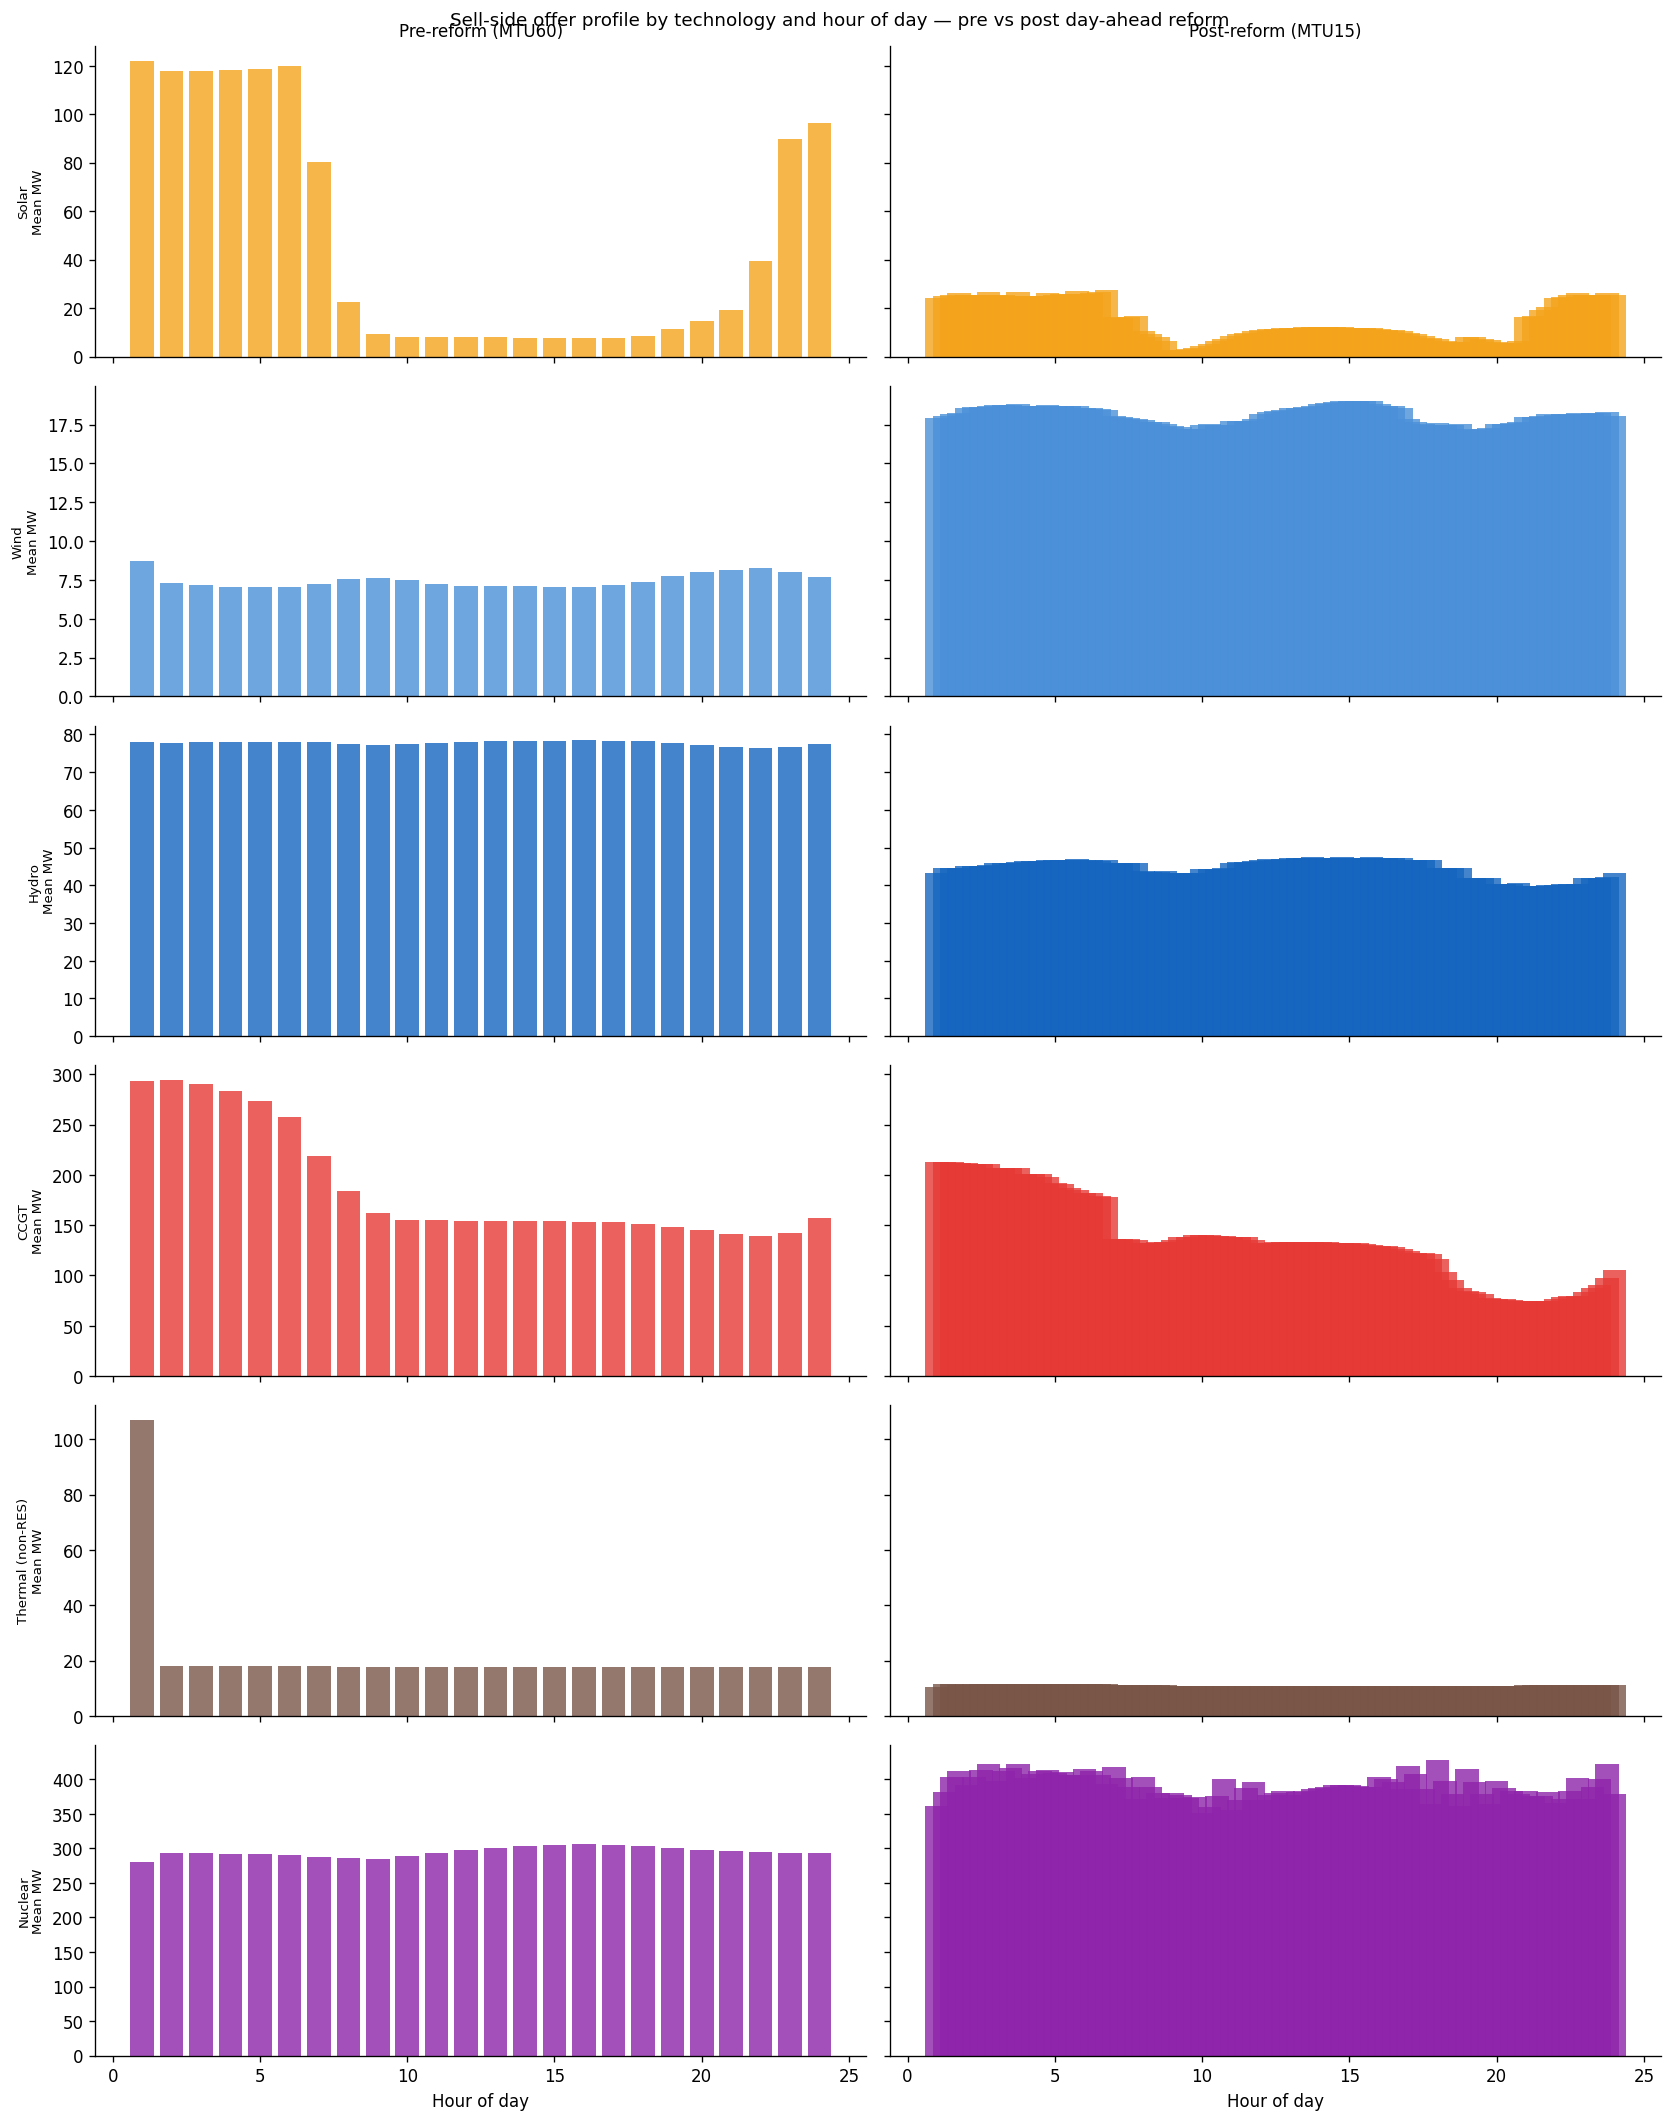

In [451]:
profile = con_det.execute(f"""
    WITH base AS (
        SELECT d.date, d.quantity_mw, d.mtu_minutes,
               CASE WHEN d.mtu_minutes = 60 THEN CAST(d.period AS INT)
                    ELSE (CAST(d.period AS INT) - 1) / 4 + 1
               END AS hour_of_day,
               c.unit_code
        FROM read_parquet('{DET}') d
        JOIN read_parquet('{CAB}') c
          ON d.date = c.date AND d.offer_code = c.offer_code
        WHERE c.buy_sell = 'V'
    )
    SELECT CASE
        WHEN u.technology IN ('RE Mercado Solar Fotovoltáica', 'RE Mercado Solar Térmica') THEN 'Solar'
        WHEN u.technology = 'RE Mercado Eólica'                                             THEN 'Wind'
        WHEN u.technology IN ('RE Mercado Hidráulica', 'Hidráulica Generación')             THEN 'Hydro'
        WHEN u.technology = 'Ciclo Combinado'                                               THEN 'CCGT'
        WHEN u.technology = 'Nuclear'                                                       THEN 'Nuclear'
        WHEN u.technology = 'RE Mercado Térmica no Renovab.'                               THEN 'Thermal (non-RES)'
        WHEN u.technology = 'RE Mercado Térmica Renovable'                                 THEN 'Thermal (RES)'
        ELSE 'Other/Unknown'
    END                  AS tech_group,
           CASE WHEN b.date < '{DAY_AHEAD_REFORM.date()}' THEN 'Pre-reform (MTU60)'
                ELSE 'Post-reform (MTU15)' END AS regime,
           hour_of_day,
           AVG(b.quantity_mw)          AS mean_mw
    FROM base b
    LEFT JOIN read_csv('{UNITS}') u ON b.unit_code = u.unit_code
    WHERE hour_of_day BETWEEN 1 AND 24
    GROUP BY tech_group, regime, hour_of_day
    ORDER BY tech_group, regime, hour_of_day
""").df()

focus_techs = ['Solar', 'Wind', 'Hydro', 'CCGT', 'Thermal (non-RES)', 'Nuclear']
regimes     = ["Pre-reform (MTU60)", "Post-reform (MTU15)"]

fig, axes = plt.subplots(len(focus_techs), 2, figsize=(14, 3 * len(focus_techs)), sharey="row", sharex=True)

for row_i, tech in enumerate(focus_techs):
    sub = profile[profile["tech_group"] == tech]
    for col_i, regime in enumerate(regimes):
        ax   = axes[row_i][col_i]
        data = sub[sub["regime"] == regime].sort_values("hour_of_day")
        if not data.empty:
            ax.bar(data["hour_of_day"], data["mean_mw"],
                   color=TECH_COLORS[tech], alpha=0.8, width=0.8)
        if col_i == 0:
            ax.set_ylabel(f"{tech}\nMean MW", fontsize=8)
        if row_i == 0:
            ax.set_title(regime, fontsize=10)
        if row_i == len(focus_techs) - 1:
            ax.set_xlabel("Hour of day")

fig.suptitle("Sell-side offer profile by technology and hour of day — pre vs post day-ahead reform", fontsize=11)
plt.tight_layout()
plt.show()
